In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

import numpy as np
from scipy.interpolate import interp1d
from iminuit import Minuit
import math as math
import warnings
import sys
import os
from scipy.linalg import inv, pinvh
from scipy import interpolate 
from scipy.interpolate import RegularGridInterpolator

current_dir = os.getcwd()
sys.path.append(os.path.join(current_dir, 'Prompt_spectra'))

from Prompt_spectra import GammaSpectrumInterpolator as Interpolator

def exctractcirellitable(DMmass,DMchannel,particle,EWcorr):
    warnings.filterwarnings("ignore", category=DeprecationWarning)

    '''
    This function returns the energy spectrum in 1/GeV for the particle production from DM annihilation.
    These results come from the PPPC4DM http://www.marcocirelli.net/PPPC4DMID.html
    Relevant tables should be downloaded and stored locally
    
    DMmass: dark matter mass in GeV
    DMchannel: dark matter annihilation channel with EW correction (no EW correction)
    e 4 (2), mu 7 (3), tau 10 (4), bb 13 (7), tt 14 (8), WW 17 (9), ZZ 20 (10), gamma 22 (12), h 23 (13)
    particle: particle produced from the DM annihilation ('gammas' or 'positrons')
    EWcorr: electroweak corrections ('Yes' or 'No')
    '''

    if EWcorr=='Yes':
        listenergies = 179
        energy_vec = np.arange(-8.9,0.05,0.05)
    elif EWcorr=='No':
        listenergies = 180
        energy_vec = np.arange(-8.95,0.05,0.05)
    else:
        print('Error Wrong value for EWcorr, Yes or No')
    
    energy = np.zeros(listenergies)
    fluxDM = np.zeros(listenergies)
    
    base_pppc4_path = './PPPC4/particle_data' 
    
    if EWcorr=='No': 
        table = np.loadtxt(f'{base_pppc4_path}/AtProduction{EWcorr}EW_{particle}.dat', skiprows=1)
    else:
        table = np.loadtxt(f'{base_pppc4_path}/AtProduction_{particle}.dat', skiprows=1)
        
    massvec = []
    for t in range(len(table)):
        if t%listenergies == 0:
            massvec.append(table[t,0])
    massvec = np.array(massvec)
    
    flux = []
    for t in range(len(table)):
        flux.append(table[t,DMchannel])
    
    f = interpolate.interp2d(massvec, energy_vec, flux, kind='linear')
    
    for t in range(len(energy_vec)):
        fluxDM[t] = f(DMmass,energy_vec[t])
    
    return np.power(10.,energy_vec)*DMmass, fluxDM/(np.log(10.)*np.power(10.,energy_vec)*DMmass)

In [2]:
exctractcirellitable

<function __main__.exctractcirellitable(DMmass, DMchannel, particle, EWcorr)>

## Prompt signal preparation

In [22]:
import os
import glob
import re
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator, interp1d
import matplotlib.pyplot as plt

_MG5_DATA_CACHE = {}

class MG5Interpolator:
    """
    A class that reads the user's MG5 CSV data and performs 2D interpolation (Mass, Energy).
    It has been designed to be compatible with the existing Interpolator class and its usage.
    """
    def __init__(self, mass, channel='bb', 
                 base_dir='/home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_bb/'):
        self.target_mass = float(mass)
        self.channel = channel
        self.base_dir = base_dir
        
        cache_key = (base_dir, channel)
        
        if cache_key not in _MG5_DATA_CACHE:
            print(f"[{channel}] data loading... (directory: {base_dir})")
            _MG5_DATA_CACHE[cache_key] = self._build_interpolator(base_dir, channel)
            
        self.interp_func, self.common_energy_grid = _MG5_DATA_CACHE[cache_key]

    def _build_interpolator(self, base_dir, channel):
        pattern = os.path.join(base_dir, f"MM_mpsi*GeV_{channel}_photon.csv")
        files = glob.glob(pattern)
        
        if not files:
            raise FileNotFoundError(f"File is not founded. please check the directory and pattern:\n{pattern}")

        data_list = []
        for fpath in files:
            fname = os.path.basename(fpath)
            match = re.search(r"MM_mpsi([0-9\.]+)GeV", fname)
            if match:
                mass = float(match.group(1))
                try:
                    df = pd.read_csv(fpath)
                    if 'Energy_GeV' in df.columns and 'dNdE' in df.columns:
                        df = df.sort_values('Energy_GeV')
                        data_list.append({
                            'mass': mass,
                            'energy': df['Energy_GeV'].values,
                            'dNdE': df['dNdE'].values
                        })
                except Exception as e:
                    print(f"⚠️ {fname} reading fail: {e}")

        if not data_list:
            raise ValueError("No valid CSV data was loaded.")

        data_list.sort(key=lambda x: x['mass'])
        dm_masses = np.array([x['mass'] for x in data_list])
        
        min_e = 1e-5 # 10 keV
        max_e = max([x['energy'][-1] for x in data_list])
        common_energy = np.geomspace(min_e, max_e, 500) # 500 bins
        
        flux_matrix = []
        for item in data_list:
            f = interp1d(item['energy'], item['dNdE'], bounds_error=False, fill_value=0.0)
            flux_matrix.append(f(common_energy))
            
        flux_matrix = np.array(flux_matrix)
        
        interp = RegularGridInterpolator(
            (dm_masses, np.log10(common_energy)), 
            flux_matrix, 
            bounds_error=False, 
            fill_value=0.0
        )
        
        print(f"✅ loading finish! (mass range: {dm_masses.min():.1f} ~ {dm_masses.max():.1f} GeV, {len(dm_masses)} files)")
        return interp, common_energy

    def interpolated_table(self):
        """
        Spectrum return for self.target_mass
        Returns: (Energy_Array, dNdE_Array)
        """
        pts = np.column_stack([
            np.full_like(self.common_energy_grid, self.target_mass),
            np.log10(self.common_energy_grid)
        ])
        
        dNdE = self.interp_func(pts)
        mask = self.common_energy_grid <= self.target_mass
        dNdE[~mask] = 0.0
        
        return self.common_energy_grid, dNdE

[bb] data loading... (directory: /home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_bb/)
✅ loading finish! (mass range: 5.0 ~ 1000.0 GeV, 99 files)
PPPC4 data load failure (ignorable): `interp2d` has been removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
https://scipy.github.io/devdocs/tutorial/interpolate/interp_transition_guide.html



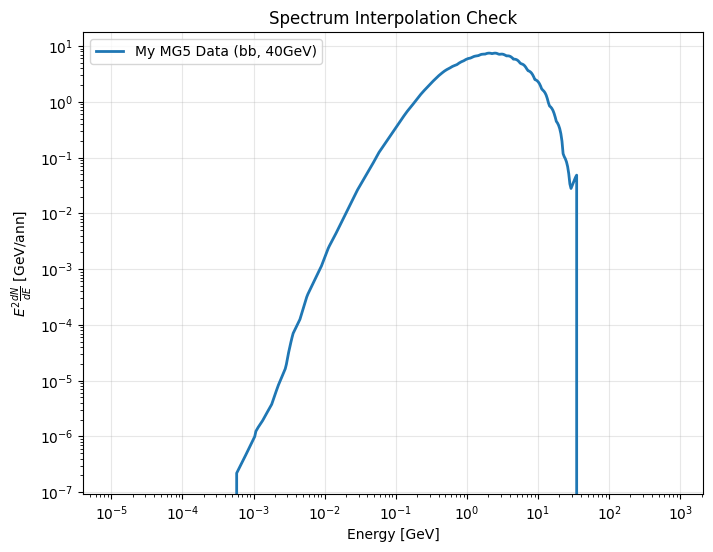

In [5]:
table = MG5Interpolator(40, 'bb').interpolated_table()

plt.figure(figsize=(8,6))
plt.loglog(table[0], (table[0]**2) * table[1], label='My MG5 Data (bb, 40GeV)', lw=2)

try:
    cirelli = exctractcirellitable(40, 13, 'gammas', 'Yes')
    plt.loglog(cirelli[0], cirelli[0]**2*cirelli[1], label='PPPC4 Reference', ls='--')
except Exception as e:
    print(f"PPPC4 data load failure (ignorable): {e}")

plt.legend()
#plt.xlim(1e-1, 100)
#plt.ylim(1e-6, 1e-3)
plt.xlabel("Energy [GeV]")
plt.ylabel(r"$E^2 \frac{dN}{dE}$ [GeV/ann]")
plt.title("Spectrum Interpolation Check")
plt.grid(alpha=0.3)
plt.show()

In [6]:
gce_data_path = './GCE_data/GCE_model_X_front_16yr_cholis.dat'
data = np.loadtxt(gce_data_path)

energy_data = data[:, 0]
flux_data   = data[:, 1]
error_data  = data[:, 2]

cov_path = './Cov/GDE_covariance_matrix_front_17x17_16yr.npy' 
cov_matrix = np.load(cov_path)

print(f"Number of flux data: {len(flux_data)}")
print(f"Covariance matrix: {cov_matrix.shape}")

if len(flux_data) != cov_matrix.shape[0]:
    print("⚠️ The dimensions still don't match. Please double-check the data file.")
else:
    print("✅ Dimension matching! Proceeding with inverse matrix calculation.")
    
    inv_cov_matrix = inv(cov_matrix)

Number of flux data: 17
Covariance matrix: (17, 17)
✅ Dimension matching! Proceeding with inverse matrix calculation.


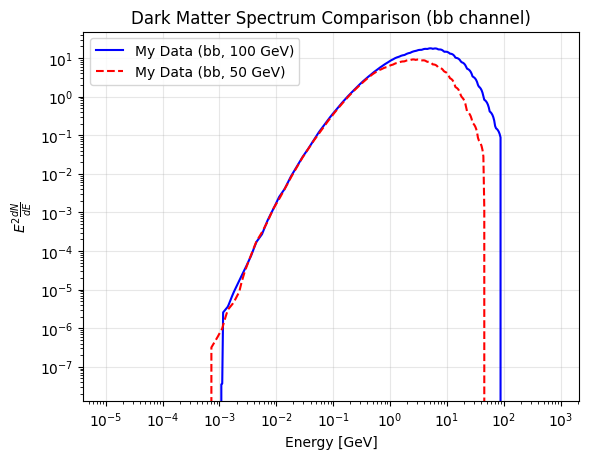

In [7]:
try:
    table_100 = MG5Interpolator(100, 'bb').interpolated_table()
    plt.loglog(table_100[0], table_100[0]**2 * table_100[1], 
               label='My Data (bb, 100 GeV)', color='blue')
except Exception as e:
    print(f"100GeV data load failure: {e}")

try:
    table_50 = MG5Interpolator(50, 'bb').interpolated_table()
    plt.loglog(table_50[0], table_50[0]**2 * table_50[1], 
               label='My Data (bb, 50 GeV)', linestyle='dashed', color='red')
except Exception as e:
    print(f"50GeV data load faulure: {e}")

#plt.xlim(1e-2, 200)   
#plt.ylim(1e-6, 1e-3)  
plt.xlabel("Energy [GeV]")
plt.ylabel(r"$E^2 \frac{dN}{dE}$")
plt.title("Dark Matter Spectrum Comparison (bb channel)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
from scipy import interpolate 
from scipy.interpolate import RegularGridInterpolator
import numpy as np
import warnings
import os

def exctractcirellitable(DMmass, DMchannel, particle, EWcorr):
    warnings.filterwarnings("ignore", category=DeprecationWarning)

    '''
    This function returns the energy spectrum in 1/GeV for the particle production from DM annihilation.
    Results from PPPC4DMID: http://www.marcocirelli.net/PPPC4DMID.html
    '''

    if EWcorr == 'Yes':
        listenergies = 179
        energy_vec = np.arange(-8.9, 0.05, 0.05)
    elif EWcorr == 'No':
        listenergies = 180
        energy_vec = np.arange(-8.95, 0.05, 0.05)
    else:
        print('Error Wrong value for EWcorr, Yes or No')
        return None, None
    
    energy = np.zeros(listenergies)
    fluxDM = np.zeros(listenergies)
    
    base_path = './PPPC4/particle_data'
    
    try:
        if EWcorr == 'No': 
            file_path = f'{base_path}/AtProduction{EWcorr}EW_{particle}.dat'
        else:
            file_path = f'{base_path}/AtProduction_{particle}.dat'
            
        table = np.loadtxt(file_path, skiprows=1)
        
    except FileNotFoundError:
        print(f"Error: The file cannot be found. Please check the path.: {file_path}")
        return np.array([]), np.array([])

    massvec = []
    for t in range(len(table)):
        if t % listenergies == 0:
            massvec.append(table[t, 0])
    massvec = np.array(massvec)
    
    flux = []
    for t in range(len(table)):
        flux.append(table[t, DMchannel])
    
    f = interpolate.interp2d(massvec, energy_vec, flux, kind='linear')
    
    for t in range(len(energy_vec)):
        fluxDM[t] = f(DMmass, energy_vec[t])
    
    return np.power(10., energy_vec) * DMmass, fluxDM / (np.log(10.) * np.power(10., energy_vec) * DMmass)

In [9]:
import numpy as np
from scipy.linalg import inv

# --------------------------------------------------------------------------
# 1. GCE Flux data load (Model X, 16yr)
# --------------------------------------------------------------------------
file_path = './GCE_data/GCE_model_X_front_16yr_cholis.dat'
data = np.loadtxt(file_path)

energy = data[:, 0]      # GeV
flux_data = data[:, 1]   # dN/dE * E^2

if data.shape[1] >= 3:
    error_data = data[:, 2]
else:
    error_data = np.zeros_like(flux_data)
    print("⚠️ Warning: There is no error column in the data file.")

GCE_data_E_i = energy
GCE_data_i   = flux_data
GCE_data_err_i = error_data


# --------------------------------------------------------------------------
# 2. Covariance Matrix Load
# --------------------------------------------------------------------------
cov_path = './Cov/GDE_covariance_matrix_front_17x17_16yr.npy'
cov_matrix = np.load(cov_path)


# --------------------------------------------------------------------------
# 3. Calculating Inverse Covariance Matrix - Chi-square needed
# --------------------------------------------------------------------------
try:
    inv_GCE_data_err_matrix = inv(cov_matrix)
    print("✅ Inverse Covariance Matrix Calculation Complete")
except Exception as e:
    print(f"❌ Inverse Covariance Matrix Calculation failure: {e}")


# --------------------------------------------------------------------------
# 4. Data check
# --------------------------------------------------------------------------
print(f"Number of Flux data: {len(flux_data)}")
print(f"Covariance matrix dimension: {cov_matrix.shape}")

if len(flux_data) != cov_matrix.shape[0]:
    print(f"❌ [Critical Error] data dimension({len(flux_data)})and covariance matrix({cov_matrix.shape[0]})is not matching")
else:
    print("✅ Data loading and setup complete. Proceed to the next step (Chi-square fitting).")

✅ Inverse Covariance Matrix Calculation Complete
Number of Flux data: 17
Covariance matrix dimension: (17, 17)
✅ Data loading and setup complete. Proceed to the next step (Chi-square fitting).


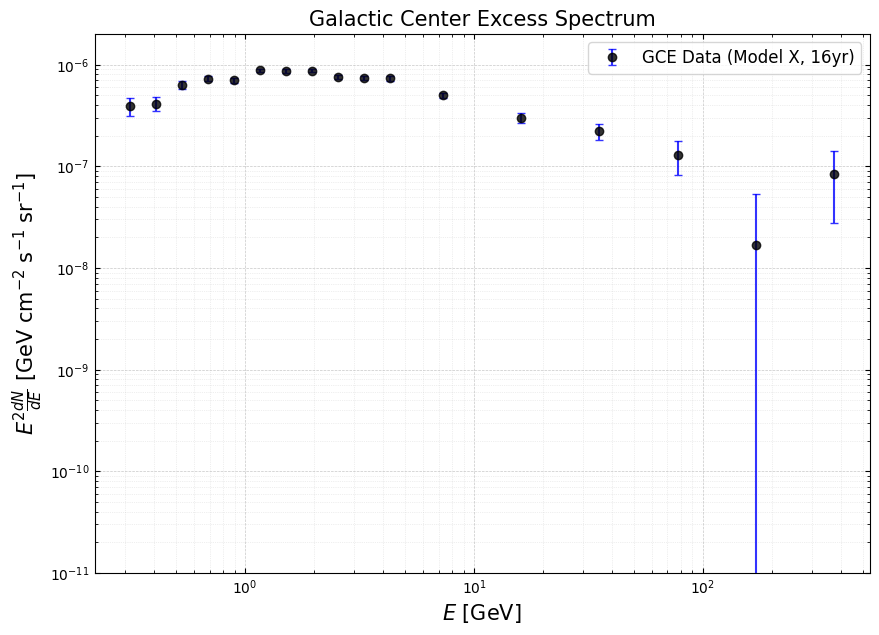

In [65]:
plt.figure(figsize=(10, 7))
plt.loglog()
plt.ylim(1e-11, 2e-6)  
plt.style.use('default')
plt.tick_params(axis='y', which='both', direction='in', right=True)
plt.tick_params(axis='x', which='both', direction='in', top=True)
plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.4)

plt.errorbar(energy, flux_data, yerr=error_data, 
             fmt='o',            
             color='black',      
             ecolor='blue',      
             capsize=3,          
             label='GCE Data (Model X, 16yr)', 
             alpha=0.8)

plt.xlabel(r'$E$ [GeV]', fontsize=15)
plt.ylabel(r'${E}^2 \frac{{dN}}{{dE}}$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=15)
plt.title("Galactic Center Excess Spectrum", fontsize=15)
plt.legend(fontsize=12, frameon=True)
plt.show()

In [66]:
import numpy as np

model = 'X'       
front = 'front'   

file_path = f'./GCE_data/GCE_model_{model}_{front}_16yr_cholis.dat'
print(f"Loading: {file_path}")

try:
    i = np.loadtxt(file_path)
    
    GCE_data_E_i = i[:, 0]  # Energy
    GCE_data_i   = i[:, 1]  # Flux
    
    if i.shape[1] >= 5:
        GCE_data_err_i = i[:, 2]                 # Statistical error
        GCE_data_E_lower_i = GCE_data_i - i[:, 3] # Lower Error
        GCE_data_E_upper_i = i[:, 4] - GCE_data_i # Upper Error
        print("✅ Asymmetric Errors has been loaded.")
        
    else:
        GCE_data_err_i = i[:, 2]
        GCE_data_E_lower_i = i[:, 2] 
        GCE_data_E_upper_i = i[:, 2] 
        print("ℹ️ Symmetric Errors are used. (Number of columns < 5)")

except FileNotFoundError:
    print(f"❌ File not found: {file_path}")
    print("Please double-check the path and filename.")

except IndexError:
    print("❌ Data column index error. Please check the file contents.")

Loading: ./GCE_data/GCE_model_X_front_16yr_cholis.dat
✅ Asymmetric Errors has been loaded.


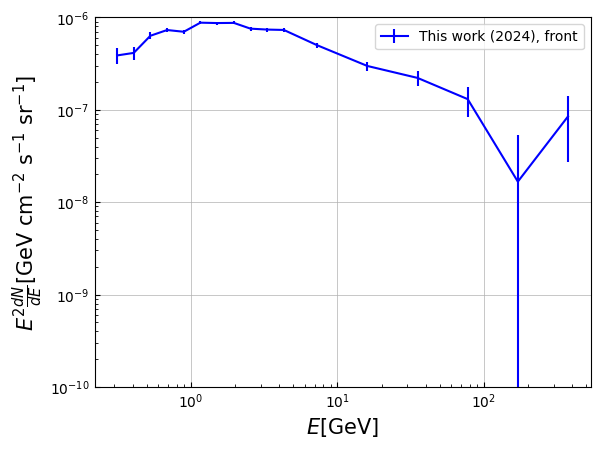

In [67]:
plt.loglog()
plt.ylim(1e-10, 1e-6)
plt.style.use('default')
plt.tick_params(axis='y', which='both', direction='in', left=True)
plt.tick_params(axis='x', which='both', direction='in', bottom=True)
#plt.minorticks_on()
plt.grid(True, which='Major', linestyle='-', linewidth=0.5)

plt.errorbar(GCE_data_E_i, GCE_data_i, yerr=GCE_data_err_i, label=f'This work (2024), {front}', alpha=1, color='blue')


plt.xlabel('$E$[GeV]', fontsize=15)
plt.ylabel(r'${E}^2 \frac{{dN}}{{dE}}$[GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=15)

plt.legend()

✅ Systematic Error Band Load Success


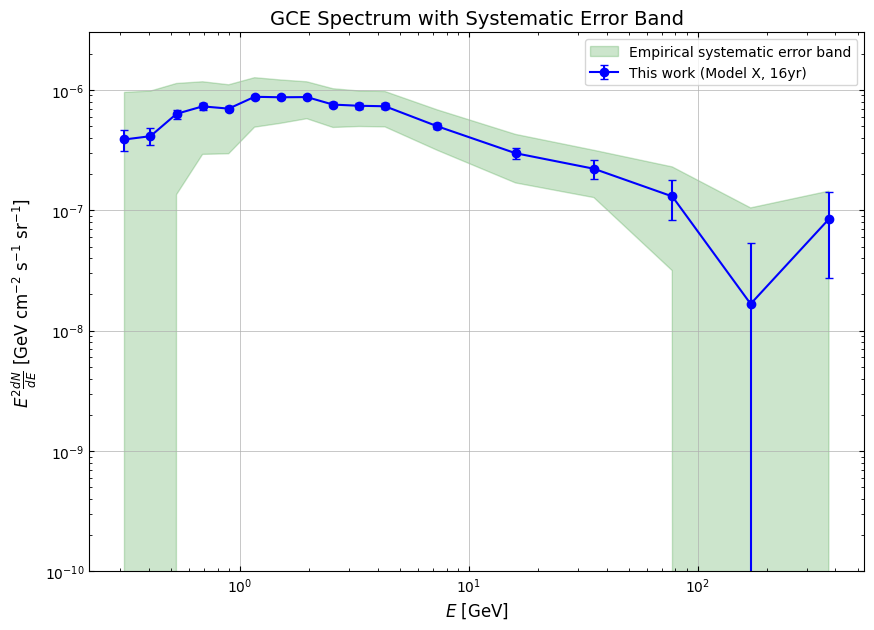

In [68]:
plt.figure(figsize=(10, 7))
plt.loglog()
plt.ylim(1e-10, 3e-6) 
plt.style.use('default')
plt.tick_params(axis='y', which='both', direction='in', right=True)
plt.tick_params(axis='x', which='both', direction='in', top=True)
plt.minorticks_on()
plt.grid(True, which='major', linestyle='-', linewidth=0.5)

sys_cov_path = './Cov/approx_covariance_17x17_front_model_X_16yr.npy'

try:
    sys_cov_matrix = np.load(sys_cov_path)
    sys_sigma = np.sqrt(np.diag(sys_cov_matrix))
    
    plt.fill_between(GCE_data_E_i, 
                     GCE_data_i - sys_sigma, 
                     GCE_data_i + sys_sigma, 
                     color='green', alpha=0.2, 
                     label='Empirical systematic error band')
    print("✅ Systematic Error Band Load Success")
    
except FileNotFoundError:
    print(f"⚠️ The file is missing, so I was unable to draw the systematic error band.: {sys_cov_path}")
except Exception as e:
    print(f"⚠️ Error occurred: {e}")

plt.errorbar(GCE_data_E_i, GCE_data_i, yerr=GCE_data_err_i, 
             label='This work (Model X, 16yr)', 
             fmt='o-',           
             linewidth=1.5,      
             color='blue', 
             ecolor='blue', 
             capsize=3, 
             alpha=1)

plt.ylabel(r'$E^2 \frac{dN}{dE}$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=12)
plt.xlabel(r'$E$ [GeV]', fontsize=12)
plt.title("GCE Spectrum with Systematic Error Band", fontsize=14)
plt.legend(fontsize=10)
plt.show()

Chi-square scan start (Model X vs bb channel)...
✅ Scan Complete!


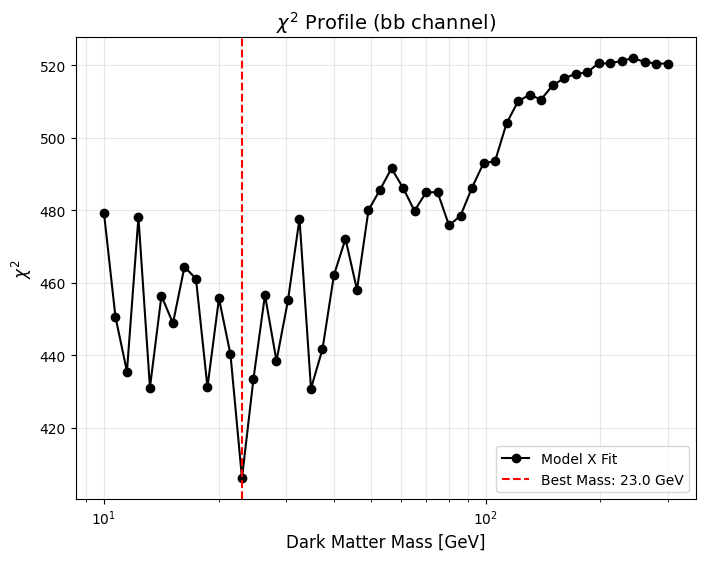

--- Conclusion ---
Best dark matter mass: 23.00 GeV
Minimum Chi-square value: 406.14
Degree of freedom: 16 (data point 17 - Parameter 1)
Reduced Chi-square: 25.38


In [69]:
from iminuit import Minuit
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. Set the mass range to scan
# -----------------------------------------------------------------------------
scan_masses = np.geomspace(10, 300, 50)
chi2_results = []
best_norms = []

# -----------------------------------------------------------------------------
# 2. Chi-square Function Definition (The objective Minuit minimizes)
# -----------------------------------------------------------------------------
def get_chi2_for_mass(mass, norm):
    try:
        energies, dNdE = MG5Interpolator(mass, 'bb').interpolated_table()
    except Exception:
        return 1e9

    model_flux = np.interp(GCE_data_E_i, energies, dNdE)
    predicted_flux = norm * (model_flux * (GCE_data_E_i**2))
    delta = GCE_data_i - predicted_flux
    chi2 = delta.T @ inv_GCE_data_err_matrix @ delta
    
    return chi2

# -----------------------------------------------------------------------------
# 3. Mass-Based Fitting Loop (Profiling)
# -----------------------------------------------------------------------------
print("Chi-square scan start (Model X vs bb channel)...")

for m in scan_masses:
    def objective(norm):
        return get_chi2_for_mass(m, norm)
    minuit = Minuit(objective, norm=1e-5)
    minuit.limits["norm"] = (0, None) 
    minuit.errordef = Minuit.LEAST_SQUARES
    minuit.migrad()
    
    chi2_results.append(minuit.fval) 
    best_norms.append(minuit.values["norm"]) 

print("✅ Scan Complete!")

# -----------------------------------------------------------------------------
# 4. Result Plot (Chi-square vs Mass)
# -----------------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(scan_masses, chi2_results, 'o-', color='black', label='Model X Fit')

min_chi2 = np.min(chi2_results)
best_mass_idx = np.argmin(chi2_results)
best_mass = scan_masses[best_mass_idx]

plt.axvline(best_mass, color='red', linestyle='--', label=f'Best Mass: {best_mass:.1f} GeV')
plt.xlabel("Dark Matter Mass [GeV]", fontsize=12)
plt.ylabel(r"$\chi^2$", fontsize=12)
plt.title(r"$\chi^2$ Profile (bb channel)", fontsize=14)
plt.xscale('log')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

print(f"--- Conclusion ---")
print(f"Best dark matter mass: {best_mass:.2f} GeV")
print(f"Minimum Chi-square value: {min_chi2:.2f}")
print(f"Degree of freedom: {len(GCE_data_i) - 1} (data point {len(GCE_data_i)} - Parameter 1)")
print(f"Reduced Chi-square: {min_chi2 / (len(GCE_data_i) - 1):.2f}")

--- Fitting Results ---
Best Mass: 23.00 GeV
Best Norm: 9.14e-08
Min Chi2 : 406.14
1-sigma Mass Range: 23.00 GeV ~ 23.00 GeV


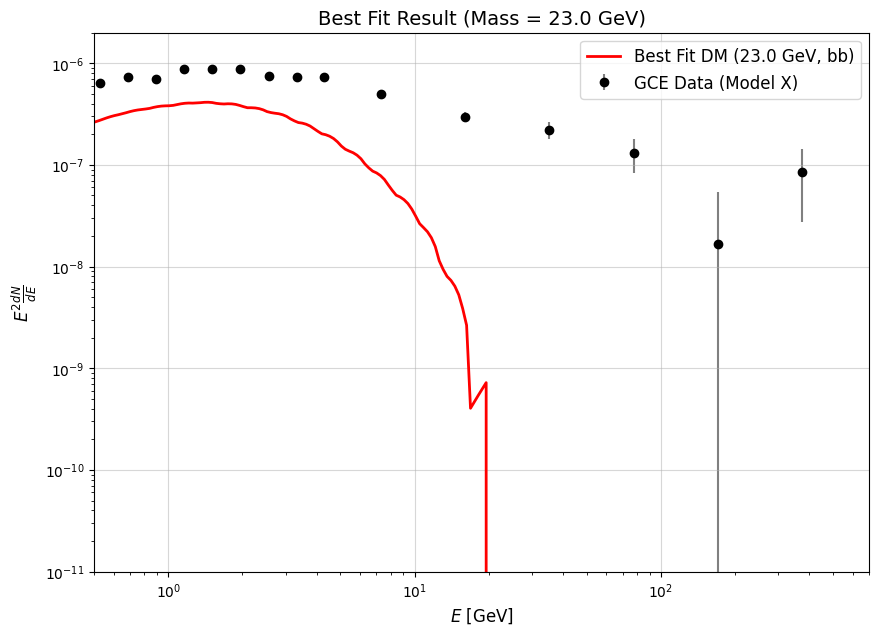

In [70]:
# -----------------------------------------------------------------------------
# 1. Retrieve Optimal Parameters (Utilizing Previous Cell Results)
# -----------------------------------------------------------------------------
# The variables chi2_results, scan_masses, and best_norms must be defined in the previous cell.
min_chi2 = np.min(chi2_results)
best_idx = np.argmin(chi2_results)

best_m = scan_masses[best_idx]
best_n = best_norms[best_idx]

print(f"--- Fitting Results ---")
print(f"Best Mass: {best_m:.2f} GeV")
print(f"Best Norm: {best_n:.2e}")
print(f"Min Chi2 : {min_chi2:.2f}")

# -----------------------------------------------------------------------------
# 2. Confidence Interval (1 sigma) Calculation
# -----------------------------------------------------------------------------
# The 1-sigma range is the interval where Delta Chi2 ≤ 1.0 (or 2.71 for a 90% confidence level).
# Here, calculations are based on the 1-sigma (68% confidence level) criterion.
threshold = 1.0
within_1sigma = np.where(np.array(chi2_results) <= min_chi2 + threshold)[0]

if len(within_1sigma) > 0:
    lower_bound_mass = scan_masses[within_1sigma[0]]
    upper_bound_mass = scan_masses[within_1sigma[-1]]
    print(f"1-sigma Mass Range: {lower_bound_mass:.2f} GeV ~ {upper_bound_mass:.2f} GeV")
else:
    print("The 1-sigma range was not found. Try scanning more densely or over a wider range.")

# -----------------------------------------------------------------------------
# 3. Poltting the Best-fit spectrum
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 7))
plt.errorbar(GCE_data_E_i, GCE_data_i, yerr=GCE_data_err_i, 
             fmt='o', color='black', ecolor='gray', label='GCE Data (Model X)', zorder=1)
try:
    e_model, flux_model = MG5Interpolator(best_m, 'bb').interpolated_table()
    plt.plot(e_model, best_n * flux_model * (e_model**2), 
             color='red', linewidth=2, label=f'Best Fit DM ({best_m:.1f} GeV, bb)')
             
except Exception as e:
    print(f"Error during model creation: {e}")

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$E$ [GeV]', fontsize=12)
plt.ylabel(r'$E^2 \frac{dN}{dE}$', fontsize=12)
plt.ylim(1e-11, 2e-6) 
plt.xlim(0.5, 700)
plt.title(f"Best Fit Result (Mass = {best_m:.1f} GeV)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, which='major', alpha=0.5)

plt.show()

In [71]:
null_delta = GCE_data_i 
chi2_null = null_delta.T @ inv_GCE_data_err_matrix @ null_delta

ts_value = chi2_null - min_chi2
sigma_significance = np.sqrt(ts_value) if ts_value > 0 else 0

print(f"--- Statistical Significance ---")
print(f"Chi2 (Null, No DM): {chi2_null:.2f}")
print(f"Chi2 (Best Fit)   : {min_chi2:.2f}")
print(f"TS (Test Statistic): {ts_value:.2f}")
print(f"Significance       : {sigma_significance:.2f} sigma")

--- Statistical Significance ---
Chi2 (Null, No DM): 523.93
Chi2 (Best Fit)   : 406.14
TS (Test Statistic): 117.79
Significance       : 10.85 sigma


In [27]:

J_factor_canonical = 2.0e23 
# <sigma v> = (Norm * 8 * pi * m^2) / J_factor
pi = np.pi
cross_section = (best_n * 8 * pi * (best_m**2)) / J_factor_canonical

print(f"--- Physical Interpretation ---")
print(f"Assumed J-factor : {J_factor_canonical:.2e} GeV^2/cm^5")
print(f"Dark Matter Mass : {best_m:.2f} GeV")
print(f"Fitted Norm      : {best_n:.2e}")
print(f"Calculated <σv>  : {cross_section:.3e} cm^3/s")

thermal_relic = 3e-26 

print(f"\nStandard Thermal Relic Value: {thermal_relic:.1e} cm^3/s")
ratio = cross_section / thermal_relic

print(f"ratio (Result / Standard) : {ratio:.2f} ")

if 0.1 < ratio < 10:
    print("=> Conclusion: It is very similar in size to the standard thermal WIMP model!")
else:
    print("=> Conclusion: There is a slight difference from the standard predicted value.")

NameError: name 'best_n' is not defined

--- Final Fitting Results ---
  Channel Mass (GeV) Min Chi2       P-value <sigma v>
0      bb       23.9    414.3  25.90 (Red.)  5.96e-27
1      4b       37.0    405.4  25.34 (Red.)  9.31e-27
2    4tau       21.9    502.3  31.40 (Red.)  1.40e-27
3  2b2tau       48.1    415.1  25.95 (Red.)  2.89e-26


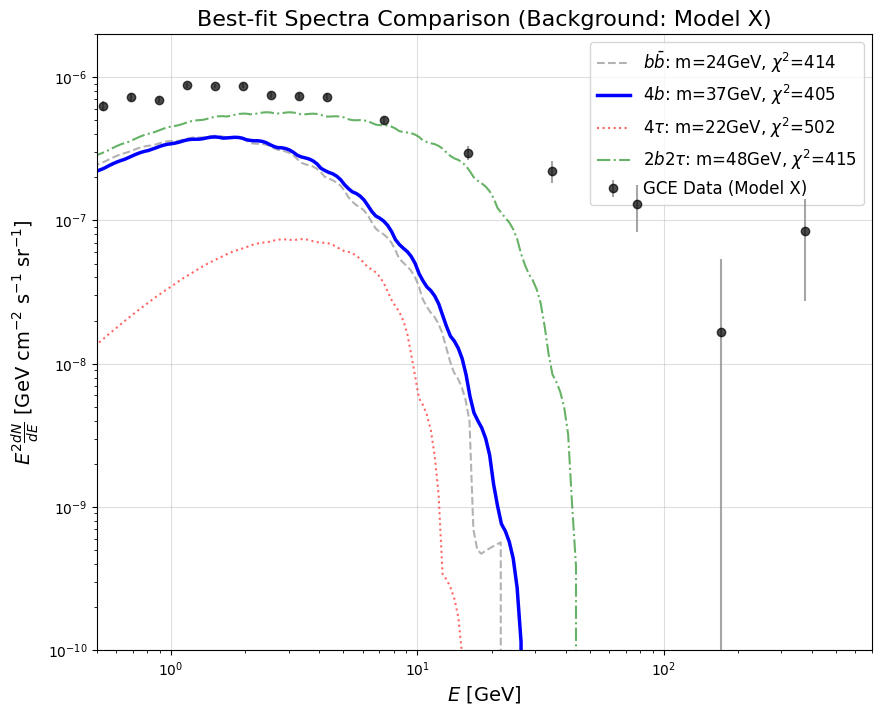

In [74]:
import pandas as pd

# -----------------------------------------------------------------------------
# 1. Settings (J-factor and constants)
# -----------------------------------------------------------------------------
J_factor = 2.0e23 # Canonical value
thermal_relic = 3e-26
results_summary = []

plt.figure(figsize=(10, 8))
plt.errorbar(GCE_data_E_i, GCE_data_i, yerr=GCE_data_err_i, 
             fmt='o', color='black', ecolor='gray', 
             label='GCE Data (Model X)', zorder=10, alpha=0.7)

# -----------------------------------------------------------------------------
# 2. Recalculation and visualization of optimal parameters for each channel
# -----------------------------------------------------------------------------
styles = {
    'bb':     {'c': 'gray',   'ls': '--', 'label': r'$b\bar{b}$'},
    '4b':     {'c': 'blue',   'ls': '-',  'label': r'$4b$'}, 
    '4tau':   {'c': 'red',    'ls': ':',  'label': r'$4\tau$'},
    '2b2tau': {'c': 'green',  'ls': '-.', 'label': r'$2b2\tau$'}
}

print("--- Final Fitting Results ---")

for ch_name, chi2_vals in results.items(): 
    if not chi2_vals: continue
    
    min_chi2 = np.min(chi2_vals)
    best_idx = np.argmin(chi2_vals)
    best_m = scan_masses[best_idx]
    
    try:
        interp = MG5Interpolator(best_m, ch_name, base_dir=channel_map[ch_name])
        energies, dNdE = interp.interpolated_table()
        
        def objective(norm):
            model_flux = np.interp(GCE_data_E_i, energies, dNdE)
            pred = norm * (model_flux * (GCE_data_E_i**2))
            delta = GCE_data_i - pred
            return delta.T @ inv_GCE_data_err_matrix @ delta
        
        m_minuit = Minuit(objective, norm=1e-7)
        m_minuit.limits["norm"] = (0, None)
        m_minuit.errordef = Minuit.LEAST_SQUARES
        m_minuit.migrad()
        best_n = m_minuit.values['norm']
        sigmav = (best_n * 8 * np.pi * (best_m**2)) / J_factor
        
        results_summary.append({
            'Channel': ch_name,
            'Mass (GeV)': f"{best_m:.1f}",
            'Min Chi2': f"{min_chi2:.1f}",
            'P-value': f"{min_chi2/(len(GCE_data_i)-1):.2f} (Red.)",
            '<sigma v>': f"{sigmav:.2e}"
        })

        e_plot = np.geomspace(0.5, 300, 100)
        style = styles.get(ch_name, {'c': 'k', 'ls': '-'})
        lw = 2.5 if ch_name == '4b' else 1.5
        alpha = 1.0 if ch_name == '4b' else 0.6
        
        plt.plot(energies, best_n * dNdE * (energies**2), 
                 color=style['c'], linestyle=style['ls'], linewidth=lw, alpha=alpha,
                 label=f"{style['label']}: m={best_m:.0f}GeV, $\chi^2$={min_chi2:.0f}")

    except Exception as e:
        print(f"Error processing {ch_name}: {e}")

# -----------------------------------------------------------------------------
# 3. Finalizing Results Output and Graphs
# -----------------------------------------------------------------------------
df_res = pd.DataFrame(results_summary)
print(df_res)

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-10, 2e-6)
plt.xlim(0.5, 700)
plt.xlabel(r'$E$ [GeV]', fontsize=14)
plt.ylabel(r'$E^2 \frac{dN}{dE}$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=14)
plt.title(f"Best-fit Spectra Comparison (Background: Model X)", fontsize=16)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, which='major', alpha=0.4)
plt.show()

Reloading GCE Data and Covariance Matrix...
✅ data load finish.

Fitting Millisecond Pulsar (MSP) Model...
Valid Minimum: True
MSP Min Chi2 : 391.94
  Gamma      : 1.89
  E_cut      : 10.76 GeV
⚠️ using example value.

--- Model Comparison ---
DM (2b2tau) Chi2 : 360.00
MSP Chi2          : 391.94
DM : 31.94


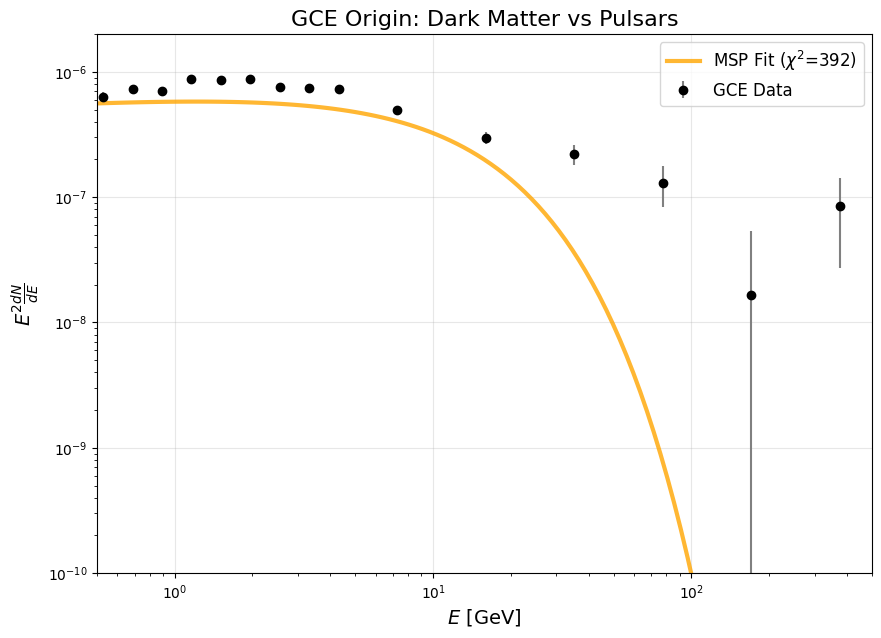

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from scipy.linalg import inv

print("Reloading GCE Data and Covariance Matrix...")

try:
    file_path = './GCE_data/GCE_model_X_front_16yr_cholis.dat'
    data = np.loadtxt(file_path)
    
    GCE_data_E_i = data[:, 0]  # Energy
    GCE_data_i   = data[:, 1]  # Flux
    
    if data.shape[1] >= 5:
        GCE_data_err_i = data[:, 2] # Asymmetric case (use stat error)
    else:
        GCE_data_err_i = data[:, 2] # Symmetric case

    cov_path = './Cov/GDE_covariance_matrix_front_17x17_16yr.npy'
    cov_matrix = np.load(cov_path)
    inv_GCE_data_err_matrix = inv(cov_matrix)
    
    print("✅ data load finish.")

except FileNotFoundError:
    print("❌ data file is not detected.")
    raise 

def msp_spectrum(energy, norm, gamma, e_cut, E0=1.0):
    return norm * (energy / E0)**(-gamma) * np.exp(-energy / e_cut)

def chi2_msp(norm, gamma, e_cut):
    dNdE = msp_spectrum(GCE_data_E_i, norm, gamma, e_cut)
    pred_flux = dNdE * (GCE_data_E_i**2)
    delta = GCE_data_i - pred_flux
    chi2 = delta.T @ inv_GCE_data_err_matrix @ delta
    return chi2

print("\nFitting Millisecond Pulsar (MSP) Model...")

m_msp = Minuit(chi2_msp, norm=1e-7, gamma=1.5, e_cut=5.0)
m_msp.limits["norm"] = (0, None)
m_msp.limits["gamma"] = (0.5, 3.0)
m_msp.limits["e_cut"] = (1.0, 20.0)
m_msp.errordef = Minuit.LEAST_SQUARES

m_msp.migrad()

print(f"Valid Minimum: {m_msp.valid}")
print(f"MSP Min Chi2 : {m_msp.fval:.2f}")
print(f"  Gamma      : {m_msp.values['gamma']:.2f}")
print(f"  E_cut      : {m_msp.values['e_cut']:.2f} GeV")

target_channel = '2b2tau'
try:
    if 'min_chi2_global' in globals():
        dm_chi2 = min_chi2_global
        best_dm_mass = best_fit_coords[0] 
    else:
        dm_chi2 = 360.0
        best_dm_mass = 45.0
        print("⚠️ using example value.")

    print(f"\n--- Model Comparison ---")
    print(f"DM ({target_channel}) Chi2 : {dm_chi2:.2f}")
    print(f"MSP Chi2          : {m_msp.fval:.2f}")
    
    diff = dm_chi2 - m_msp.fval
    if diff > 0:
        print(f"MSP : {diff:.2f}")
    else:
        print(f"DM : {abs(diff):.2f}")

except Exception as e:
    print(f"error : {e}")

plt.figure(figsize=(10, 7))
plt.errorbar(GCE_data_E_i, GCE_data_i, yerr=GCE_data_err_i, 
             fmt='o', color='black', ecolor='gray', label='GCE Data')

e_range = np.geomspace(0.5, 200, 100)
msp_flux = msp_spectrum(e_range, m_msp.values['norm'], m_msp.values['gamma'], m_msp.values['e_cut'])
plt.plot(e_range, msp_flux * (e_range**2), color='orange', linewidth=3, alpha=0.8,
         label=f'MSP Fit ($\chi^2$={m_msp.fval:.0f})')

try:
    if 'channel_map' in globals():
        interp_dm = MG5Interpolator(best_dm_mass, target_channel, base_dir=channel_map[target_channel])
        e_dm, dNdE_dm = interp_dm.interpolated_table()
        scale = np.max(GCE_data_i) / np.max(dNdE_dm * (e_dm**2)) * 0.8 
        plt.plot(e_dm, scale * dNdE_dm * (e_dm**2), color='green', linestyle='--', linewidth=2,
                 label=f'DM {target_channel} shape')
except:
    pass

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-10, 2e-6)
plt.xlim(0.5, 500)
plt.xlabel(r'$E$ [GeV]', fontsize=14)
plt.ylabel(r'$E^2 \frac{dN}{dE}$', fontsize=14)
plt.title('GCE Origin: Dark Matter vs Pulsars', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## Photon Comparison

✅ data load success!


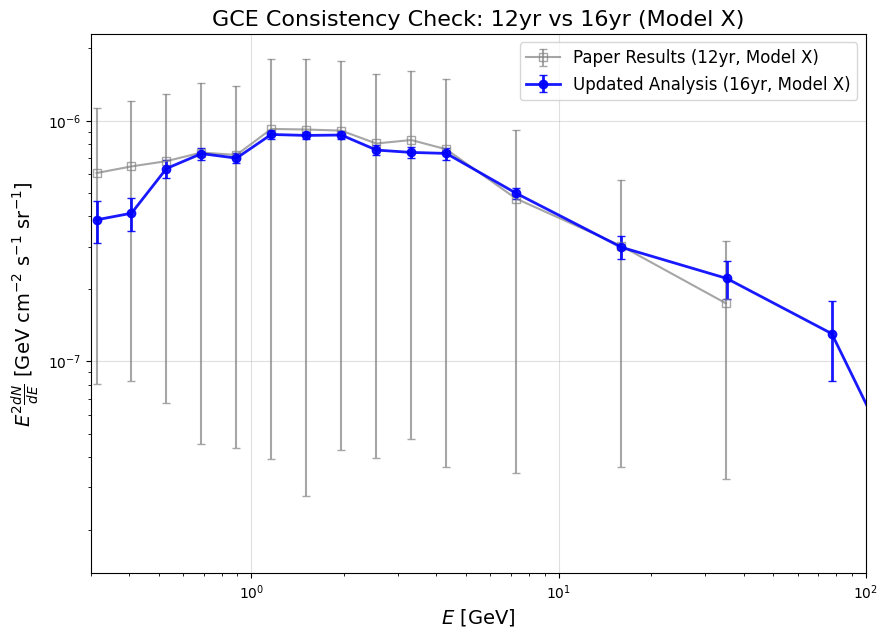

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

path_12yr_dir = './GCE_TEMPLATES_FILES_v3/Figures_12_and_14_GCE_Spectra/'
file_12yr = os.path.join(path_12yr_dir, 'GCE_ModelX_flux_Inner40x40_masked_disk.dat')

path_16yr_file = './GCE_data/GCE_model_X_front_16yr_cholis.dat'

try:
    d12 = np.loadtxt(file_12yr)
    E_12 = d12[:, 0]
    Flux_12 = d12[:, 1]

    if d12.shape[1] >= 3:
        Err_12 = d12[:, 2] 
    else:
        Err_12 = np.zeros_like(Flux_12) 

    d16 = np.loadtxt(path_16yr_file)
    E_16 = d16[:, 0]
    Flux_16 = d16[:, 1]
    if d16.shape[1] >= 3:
        Err_16 = d16[:, 2]
    else:
        Err_16 = np.zeros_like(Flux_16)

    print("✅ data load success!")

except Exception as e:
    print(f"❌ error: {e}")
    if os.path.exists(path_12yr_dir):
        print(f"example in folder: {os.listdir(path_12yr_dir)[:3]}")
    else:
        print("data directory is not correct.")
    raise

plt.figure(figsize=(10, 7))

# 12yr Data (Model X)
plt.errorbar(E_12, Flux_12, yerr=Err_12, 
             fmt='s-', color='gray', mfc='none', mec='gray', capsize=3, alpha=0.7,
             label='Paper Results (12yr, Model X)')

# 16yr Data (Model X)
plt.errorbar(E_16, Flux_16, yerr=Err_16, 
             fmt='o-', color='blue', linewidth=2, capsize=3, alpha=0.9,
             label='Updated Analysis (16yr, Model X)')


plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$E$ [GeV]', fontsize=14)
plt.ylabel(r'$E^2 \frac{dN}{dE}$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=14)
plt.title('GCE Consistency Check: 12yr vs 16yr (Model X)', fontsize=16)
#plt.ylim(1e-7, 1e-5) 
plt.xlim(0.3, 100)
plt.legend(fontsize=12)
plt.grid(True, which='major', alpha=0.4)

plt.show()

Plotting 15 background models...


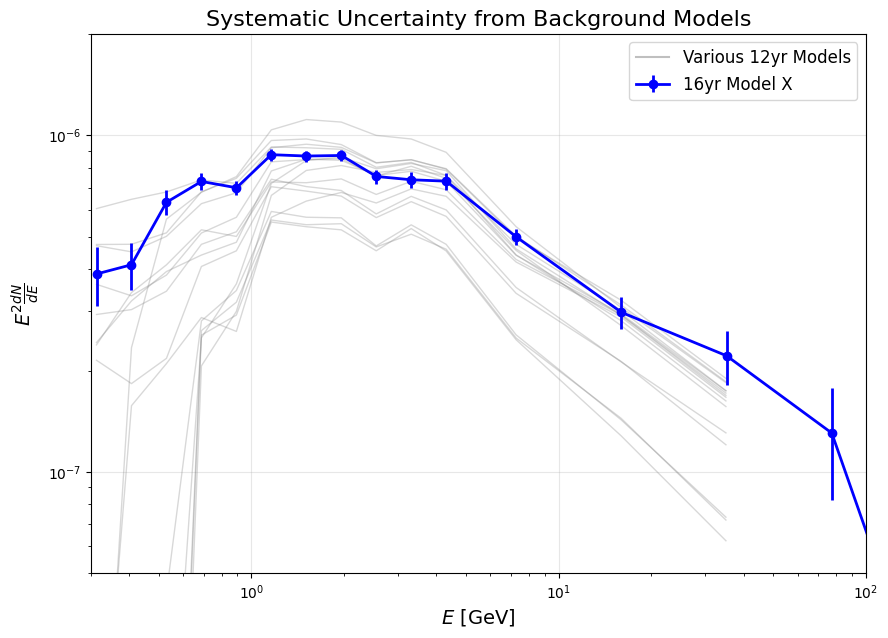

In [2]:
import glob

plt.figure(figsize=(10, 7))

all_files = glob.glob(os.path.join(path_12yr_dir, 'GCE_Model*_flux_Inner40x40_masked_disk.dat'))
selected_files = all_files[:15] 

print(f"Plotting {len(selected_files)} background models...")

for f in selected_files:
    try:
        d = np.loadtxt(f)
        fname = os.path.basename(f)
        model_name = fname.split('_')[1] 
        
        plt.plot(d[:, 0], d[:, 1], color='gray', alpha=0.3, linewidth=1)
    except:
        pass

plt.errorbar(E_16, Flux_16, yerr=Err_16, 
             fmt='o-', color='blue', linewidth=2, label='16yr Model X')

plt.plot([], [], color='gray', alpha=0.5, label='Various 12yr Models')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5e-8, 2e-6)
plt.xlim(0.3, 100)
plt.xlabel(r'$E$ [GeV]', fontsize=14)
plt.ylabel(r'$E^2 \frac{dN}{dE}$', fontsize=14)
plt.title('Systematic Uncertainty from Background Models', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

--- Loading Datasets ---
✅ Covariance Loaded & Combined for GCE_model_X_front_16yr_cholis.dat
   (Systematics from approx_covariance_17x17_front_model_X_16yr.npy + Statistics from Data)
ℹ️ Using Statistical Errors Only for GCE_ModelX_flux_Inner40x40_masked_disk.dat

Fitting 16yr Data (Model X) (bb)...

Fitting 12yr Data (Model X) (bb)...

=== Corrected Comparative Analysis Results (bb channel) ===
              label best_mass best_sigmav      min_chi2     p_value
12yr Data (Model X)     10.00    0.00e+00 1000000000.00 83333333.33
16yr Data (Model X)     10.00    0.00e+00 1000000000.00 66666666.67


NameError: name 'MG5Interpolator' is not defined

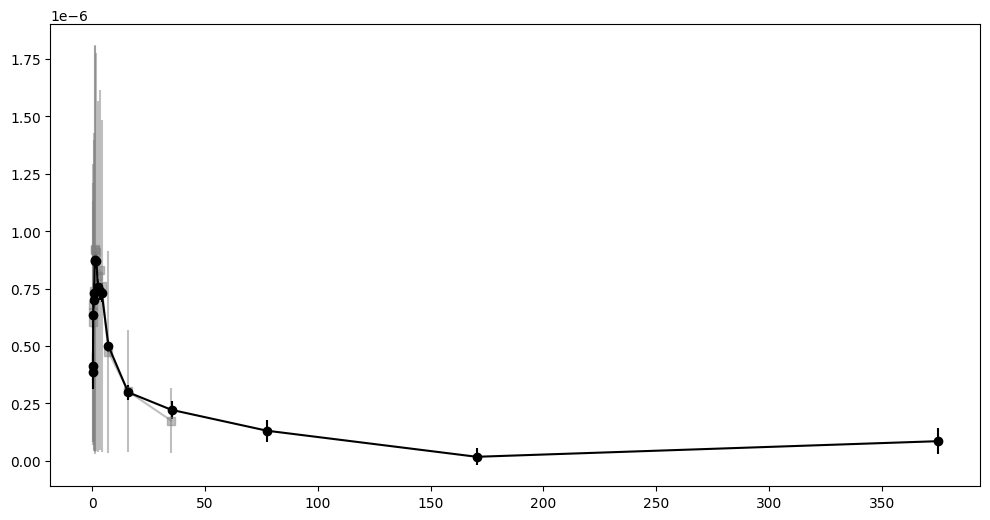

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from scipy.linalg import inv
import pandas as pd
import os


J_FACTOR = 3.5e21

path_16yr = './GCE_data/GCE_model_X_front_16yr_cholis.dat'
path_12yr = './GCE_TEMPLATES_FILES_v3/Figures_12_and_14_GCE_Spectra/GCE_ModelX_flux_Inner40x40_masked_disk.dat'
cov_path_16yr = './Cov/approx_covariance_17x17_front_model_X_16yr.npy'

channel = 'bb'

def load_gce_data(filepath, cov_path=None):
    try:
        data = np.loadtxt(filepath)
        energy = data[:, 0]
        flux = data[:, 1]

        if data.shape[1] >= 3:
            stat_err = data[:, 2]
        else:
            stat_err = np.zeros_like(flux)
            print(f"⚠️ Warning: No error column in {os.path.basename(filepath)}")

        if cov_path and os.path.exists(cov_path):
            cov_syst = np.load(cov_path)

            n = len(flux)
            if cov_syst.shape[0] > n:
                cov_syst = cov_syst[:n, :n]

            cov_stat = np.diag(stat_err**2)
            cov_total = cov_syst + cov_stat
            inv_cov = inv(cov_total)
            
            print(f"✅ Covariance Loaded & Combined for {os.path.basename(filepath)}")
            print(f"   (Systematics from {os.path.basename(cov_path)} + Statistics from Data)")
            
        else:
            cov_total = np.diag(stat_err**2)
            inv_cov = np.diag(1.0 / (stat_err**2))
            print(f"ℹ️ Using Statistical Errors Only for {os.path.basename(filepath)}")
            
        return energy, flux, stat_err, inv_cov
        
    except Exception as e:
        print(f"❌ Error loading {filepath}: {e}")
        return None

print("--- Loading Datasets ---")
data_16 = load_gce_data(path_16yr, cov_path_16yr) 
data_12 = load_gce_data(path_12yr, None)

if data_16 is None or data_12 is None:
    raise ValueError("data load fail.")

def run_fitting(dataset, label_name):
    energy_data, flux_data, err_data, inv_cov = dataset
    scan_masses = np.geomspace(10, 300, 40)
    chi2_list = []
    best_norm_list = []
    
    print(f"\nFitting {label_name} ({channel})...")
    
    for m in scan_masses:
        try:
            interp = MG5Interpolator(m, channel, base_dir='/home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_bb/')
            e_model, dNdE_model = interp.interpolated_table()
            model_flux_interp = np.interp(energy_data, e_model, dNdE_model)
            model_shape = model_flux_interp * (energy_data**2)

            def objective(norm):
                pred = norm * model_shape
                delta = flux_data - pred
                return delta.T @ inv_cov @ delta 
            
            m_minuit = Minuit(objective, norm=1e-7)
            m_minuit.limits["norm"] = (0, None)
            m_minuit.errordef = Minuit.LEAST_SQUARES
            m_minuit.migrad()
            
            chi2_list.append(m_minuit.fval)
            best_norm_list.append(m_minuit.values['norm'])
            
        except Exception as e:
            chi2_list.append(1e9)
            best_norm_list.append(0)
            
    min_chi2 = np.min(chi2_list)
    idx_best = np.argmin(chi2_list)
    best_mass = scan_masses[idx_best]
    best_norm = best_norm_list[idx_best]
    best_sigmav = (best_norm * 8 * np.pi * (best_mass**2)) / J_FACTOR
    
    return {
        'label': label_name,
        'best_mass': best_mass,
        'best_sigmav': best_sigmav,
        'min_chi2': min_chi2,
        'ndof': len(flux_data) - 2,
        'best_norm': best_norm,
        'chi2_list': chi2_list
    }

res_16 = run_fitting(data_16, "16yr Data (Model X)")
res_12 = run_fitting(data_12, "12yr Data (Model X)")

df_compare = pd.DataFrame([res_12, res_16])
df_compare['p_value'] = df_compare['min_chi2'] / df_compare['ndof'] # Reduced Chi2

print("\n=== Corrected Comparative Analysis Results (bb channel) ===")
cols = ['label', 'best_mass', 'best_sigmav', 'min_chi2', 'p_value']
print(df_compare[cols].to_string(index=False, formatters={
    'best_mass': '{:.2f}'.format,
    'best_sigmav': '{:.2e}'.format,
    'min_chi2': '{:.2f}'.format,
    'p_value': '{:.2f}'.format
}))

plt.figure(figsize=(12, 6))

plt.errorbar(data_12[0], data_12[1], yerr=data_12[2], fmt='s-', color='gray', alpha=0.5, label='12yr Data')
plt.errorbar(data_16[0], data_16[1], yerr=data_16[2], fmt='o-', color='black', label='16yr Data')

interp_16 = MG5Interpolator(res_16['best_mass'], channel, base_dir='/home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_bb/')
e_16, dNdE_16 = interp_16.interpolated_table()
plt.plot(e_16, res_16['best_norm'] * dNdE_16 * (e_16**2), color='blue', lw=2, 
         label=f"16yr Fit: {res_16['best_mass']:.1f}GeV, $\chi^2$={res_16['min_chi2']:.0f}")

# 12yr Fit
interp_12 = MG5Interpolator(res_12['best_mass'], channel, base_dir='/home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_bb/')
e_12, dNdE_12 = interp_12.interpolated_table()
plt.plot(e_12, res_12['best_norm'] * dNdE_12 * (e_12**2), color='red', ls='--', lw=2, 
         label=f"12yr Fit: {res_12['best_mass']:.1f}GeV, $\chi^2$={res_12['min_chi2']:.0f}")

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-8, 2e-6)
plt.xlim(0.2, 300)
plt.xlabel('Energy [GeV]', fontsize=12)
plt.ylabel(r'$E^2 dN/dE$', fontsize=12)
plt.title(f'Comparative Analysis: bb channel (Model X)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Processing: front, 14 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_14_bb_16yr.png


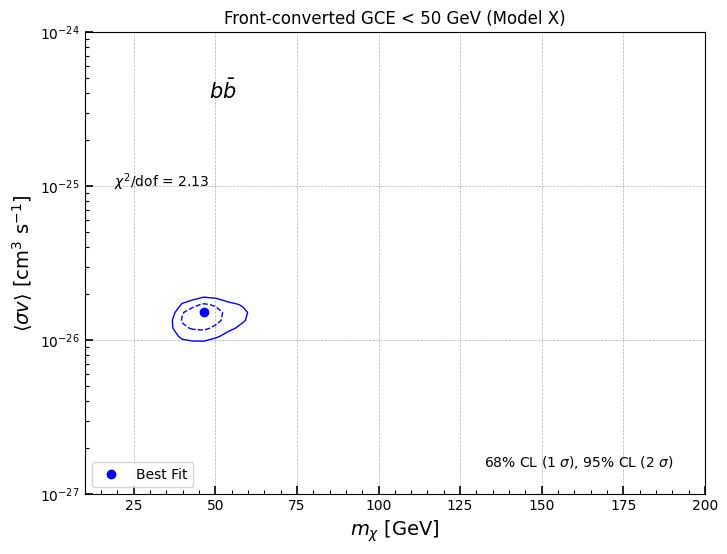

Processing: front, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_17_bb_16yr.png


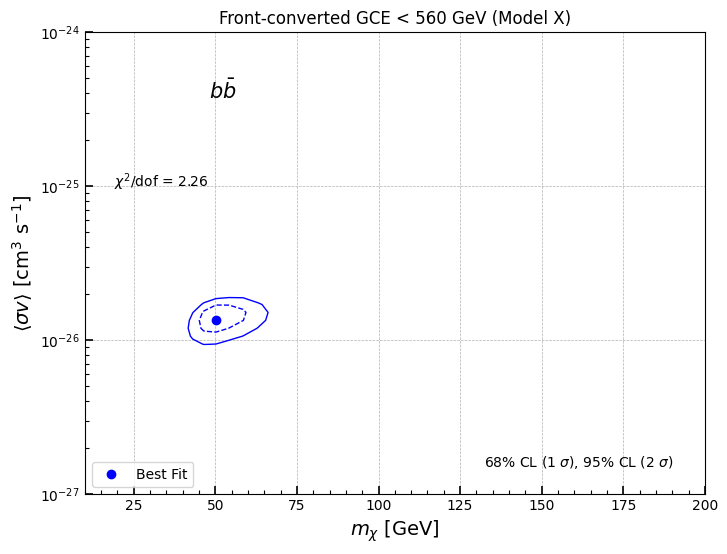

Processing: front_back, 14 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_14_bb_16yr.png


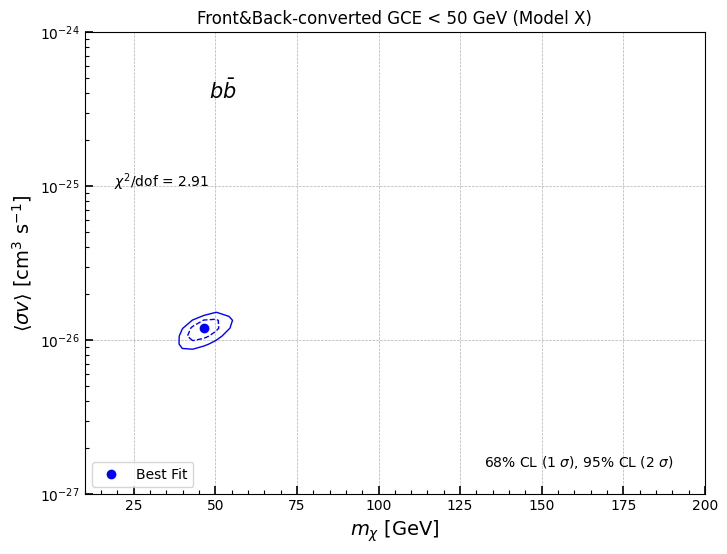

Processing: front_back, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_17_bb_16yr.png


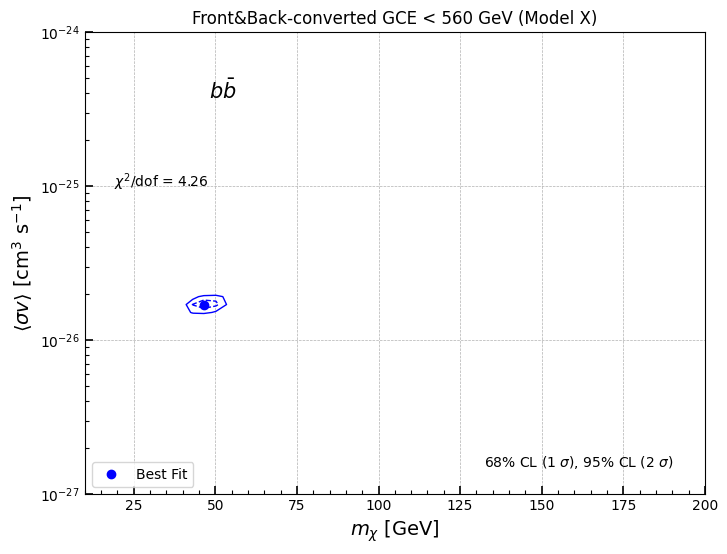

In [ ]:
# bb case chi-squared contour plot

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d, RegularGridInterpolator
from iminuit import Minuit
import warnings
import os

def exctractcirellitable(mass, channel, type_particle, EW_corrections):
    if EW_corrections == 'Yes':
        filename = f"AtProduction_{type_particle}.dat"
    else:
        filename = f"AtProduction_NoEW_{type_particle}.dat"
    
    possible_paths = ['./Prompt_spectra/', '/home/haebarg/ipynb/', './' ]
    
    full_path = None
    for p in possible_paths:
        test_path = os.path.join(p, filename)
        if os.path.exists(test_path):
            full_path = test_path
            break
            
    if full_path is None:
        raise FileNotFoundError(f"Cannot find PPPC4 file: {filename}.")

    try:
        data = np.loadtxt(full_path, skiprows=1)
    except Exception as e:
        print(f"Warning: Loading with skiprows failed ({e}), trying without...")
        data = np.loadtxt(full_path)

    m_grid = np.unique(data[:, 0]) 
    logx_grid = np.unique(data[:, 1]) 
    
    n_m = len(m_grid)
    n_x = len(logx_grid)
    z_values = data[:, channel].reshape(n_m, n_x)
    
    interp_func = RegularGridInterpolator((m_grid, logx_grid), z_values, 
                                          bounds_error=False, fill_value=None)
    
    target_logx = logx_grid 
    points = np.array([[mass, lx] for lx in target_logx]) 
    dNdlogx = interp_func(points)
    energy_axis = mass * (10**target_logx)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        dNdE = dNdlogx / (energy_axis * np.log(10))
    
    dNdE = np.nan_to_num(dNdE, nan=0.0, posinf=0.0, neginf=0.0)
    
    return energy_axis, dNdE

base_data_path = './GCE_data/'
base_cov_path = './Cov/'
output_plot_dir = './GC_analysis/GCE_plots/'

os.makedirs(output_plot_dir, exist_ok=True)

channel_name = 'bb'

J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626

for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X']:
            
            print(f"Processing: {front}, {energy_bin_length} bins, Model {model}...")

            data_file = os.path.join(base_data_path, f'GCE_model_{model}_{front}_16yr_cholis.dat')
            
            try:
                g = np.loadtxt(data_file)
                
                bin_len = int(energy_bin_length)
                emeans = g[:bin_len, 0]
                GCE_data = g[:bin_len, 1]
                stat_unc = g[:bin_len, 2] 
                
            except Exception as e:
                print(f"⚠️ data load fail ({data_file}): {e}")
                continue

            try:
                cov_file_name = f"approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_{model}_16yr.npy"
                cov_path = os.path.join(base_cov_path, cov_file_name)
                ##check this point in original code
                
                if os.path.exists(cov_path):
                    cov_emp = np.load(cov_path)
                    cov_stat = np.diag(stat_unc**2)
                    cov_total = cov_stat + cov_emp
                    inv_cov = np.linalg.inv(cov_total)
                else:
                    print(f"⚠️ there is no file: {cov_file_name}.")
                    inv_cov = np.linalg.inv(np.diag(stat_unc**2))
                    
            except Exception as e:
                print(f"⚠️ error: {e}")
                continue

            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)
                
                prompt_dat = exctractcirellitable(dm_mass, 13, 'gammas', 'Yes')
                energy_axis = prompt_dat[0]
                dNdE_vals = prompt_dat[1]
                func_interp = interp1d(energy_axis, dNdE_vals, 
                                     fill_value=0, bounds_error=False, kind='linear')
                
                dNdE_interp = func_interp(emeans)
                model_flux = (emeans**2) * dNdE_interp * (sigma_v/(dm_mass**2)) * J_FACTOR / SR
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)

            chi_square_vec = np.vectorize(chi_square)

            print(f"   scanning parameters...")

            sigmav_range = np.logspace(-27, -25, 40)
            mass_range = np.logspace(np.log10(10), np.log10(200), 40)
            
            DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

            chi2_values = chi_square_vec(DM_mass_grid, Sigmav_grid)

            min_idx = np.unravel_index(np.argmin(chi2_values), chi2_values.shape)
            best_mass = DM_mass_grid[min_idx]
            best_sigmav = Sigmav_grid[min_idx]
            min_chi2 = chi2_values[min_idx]
            
            dof = bin_len - 2 

            # Contour Levels
            levels = [min_chi2 + 2.30, min_chi2 + 6.18] 

            plt.figure(figsize=(8, 6))
            
            try:
                CS = plt.contour(DM_mass_grid, Sigmav_grid, chi2_values, 
                            levels=levels, colors='blue', linestyles=['--', '-'], linewidths=1)
            except:
                pass

            plt.plot(best_mass, best_sigmav, 'bo', label=f'Best Fit')
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24)
            
            plt.tick_params(which='major', direction='in', length=6, width=1.2)
            plt.tick_params(which='minor', direction='in', length=3, width=0.8)
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {:.2f}'.format(min_chi2/dof), 
                     transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)

            plt.text(0.2, 0.90, r'$b \bar{b}$', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)

            title_text = ""
            if front == 'front':
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front-converted GCE < {limit} GeV (Model X)'
            else:
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front&Back-converted GCE < {limit} GeV (Model X)'
            
            plt.title(title_text, fontsize=12)
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
            plt.legend(loc='lower left')

            save_name = f'GDE_model_{model}_{front}_E_{energy_bin_length}_{channel_name}_16yr.png'
            save_path = os.path.join(output_plot_dir, save_name)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"   Saved plot to: {save_path}")
            
            plt.show()

Processing: front, 14 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_14_bb_16yr_cov_model_I.png


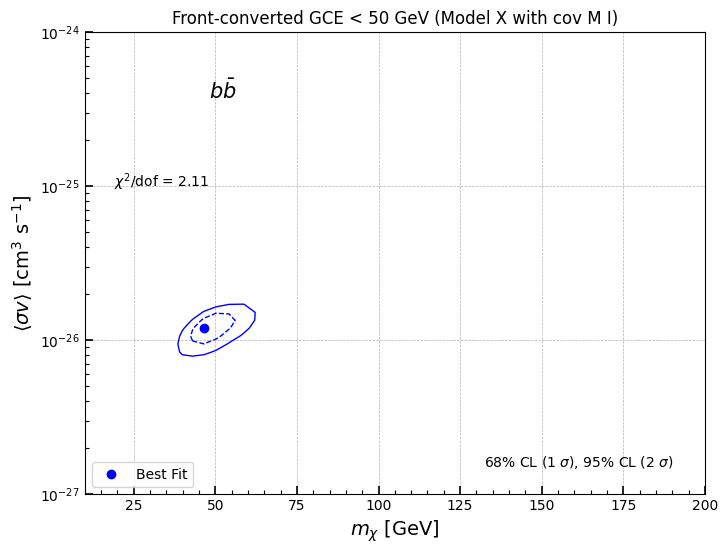

Processing: front, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_17_bb_16yr_cov_model_I.png


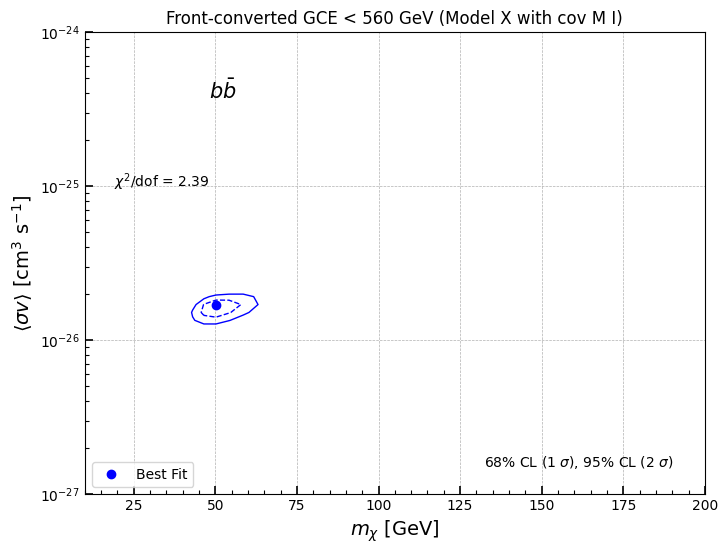

Processing: front_back, 14 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_14_bb_16yr_cov_model_I.png


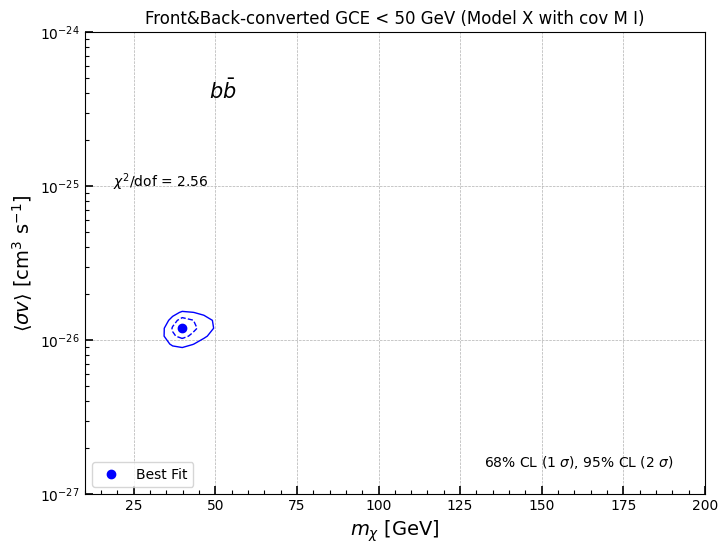

Processing: front_back, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_17_bb_16yr_cov_model_I.png


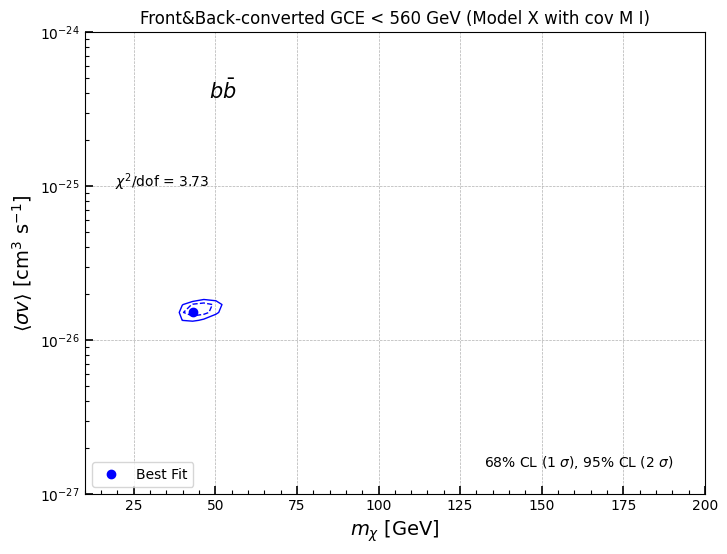

In [ ]:
#Model I Covariance matrix used of bb case chi-squared contour plot

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d, RegularGridInterpolator
from iminuit import Minuit
import warnings
import os

def exctractcirellitable(mass, channel, type_particle, EW_corrections):
    if EW_corrections == 'Yes':
        filename = f"AtProduction_{type_particle}.dat"
    else:
        filename = f"AtProduction_NoEW_{type_particle}.dat"
    
    possible_paths = ['./Prompt_spectra/', '/home/haebarg/ipynb/', './' ]
    
    full_path = None
    for p in possible_paths:
        test_path = os.path.join(p, filename)
        if os.path.exists(test_path):
            full_path = test_path
            break
            
    if full_path is None:
        raise FileNotFoundError(f"Cannot find PPPC4 file: {filename}.")

    try:
        data = np.loadtxt(full_path, skiprows=1)
    except Exception as e:
        print(f"Warning: Loading with skiprows failed ({e}), trying without...")
        data = np.loadtxt(full_path)

    m_grid = np.unique(data[:, 0]) 
    logx_grid = np.unique(data[:, 1]) 
    
    n_m = len(m_grid)
    n_x = len(logx_grid)
    z_values = data[:, channel].reshape(n_m, n_x)
    
    interp_func = RegularGridInterpolator((m_grid, logx_grid), z_values, 
                                          bounds_error=False, fill_value=None)
    
    target_logx = logx_grid 
    points = np.array([[mass, lx] for lx in target_logx]) 
    dNdlogx = interp_func(points)
    energy_axis = mass * (10**target_logx)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        dNdE = dNdlogx / (energy_axis * np.log(10))
    
    dNdE = np.nan_to_num(dNdE, nan=0.0, posinf=0.0, neginf=0.0)
    
    return energy_axis, dNdE

base_data_path = './GCE_data/'
base_cov_path = './Cov/'
output_plot_dir = './GC_analysis/GCE_plots/'

os.makedirs(output_plot_dir, exist_ok=True)

channel_name = 'bb'

J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626

for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X']:
            
            print(f"Processing: {front}, {energy_bin_length} bins, Model {model}...")

            data_file = os.path.join(base_data_path, f'GCE_model_{model}_{front}_16yr_cholis.dat')
            
            try:
                g = np.loadtxt(data_file)
                
                bin_len = int(energy_bin_length)
                emeans = g[:bin_len, 0]
                GCE_data = g[:bin_len, 1]
                stat_unc = g[:bin_len, 2] 
                
            except Exception as e:
                print(f"⚠️ data load fail ({data_file}): {e}")
                continue

            try:
                cov_file_name = f"approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_I_16yr.npy"
                cov_path = os.path.join(base_cov_path, cov_file_name)
                ##check this point in original code
                
                if os.path.exists(cov_path):
                    cov_emp = np.load(cov_path)
                    cov_stat = np.diag(stat_unc**2)
                    cov_total = cov_stat + cov_emp
                    inv_cov = np.linalg.inv(cov_total)
                else:
                    print(f"⚠️ there is no file: {cov_file_name}.")
                    inv_cov = np.linalg.inv(np.diag(stat_unc**2))
                    
            except Exception as e:
                print(f"⚠️ error: {e}")
                continue

            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)
                
                prompt_dat = exctractcirellitable(dm_mass, 13, 'gammas', 'Yes')
                energy_axis = prompt_dat[0]
                dNdE_vals = prompt_dat[1]
                func_interp = interp1d(energy_axis, dNdE_vals, 
                                     fill_value=0, bounds_error=False, kind='linear')
                
                dNdE_interp = func_interp(emeans)
                model_flux = (emeans**2) * dNdE_interp * (sigma_v/(dm_mass**2)) * J_FACTOR / SR
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)

            chi_square_vec = np.vectorize(chi_square)

            print(f"   scanning parameters...")

            sigmav_range = np.logspace(-27, -25, 40)
            mass_range = np.logspace(np.log10(10), np.log10(200), 40)
            
            DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

            chi2_values = chi_square_vec(DM_mass_grid, Sigmav_grid)

            min_idx = np.unravel_index(np.argmin(chi2_values), chi2_values.shape)
            best_mass = DM_mass_grid[min_idx]
            best_sigmav = Sigmav_grid[min_idx]
            min_chi2 = chi2_values[min_idx]
            
            dof = bin_len - 2 

            # Contour Levels
            levels = [min_chi2 + 2.30, min_chi2 + 6.18] 

            plt.figure(figsize=(8, 6))
            
            try:
                CS = plt.contour(DM_mass_grid, Sigmav_grid, chi2_values, 
                            levels=levels, colors='blue', linestyles=['--', '-'], linewidths=1)
            except:
                pass

            plt.plot(best_mass, best_sigmav, 'bo', label=f'Best Fit')
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24)
            
            plt.tick_params(which='major', direction='in', length=6, width=1.2)
            plt.tick_params(which='minor', direction='in', length=3, width=0.8)
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {:.2f}'.format(min_chi2/dof), 
                     transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)

            plt.text(0.2, 0.90, r'$b \bar{b}$', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)

            title_text = ""
            if front == 'front':
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front-converted GCE < {limit} GeV (Model X with cov M I)'
            else:
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front&Back-converted GCE < {limit} GeV (Model X with cov M I)'
            
            plt.title(title_text, fontsize=12)
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
            plt.legend(loc='lower left')

            save_name = f'GDE_model_{model}_{front}_E_{energy_bin_length}_{channel_name}_16yr_cov_model_I.png'
            save_path = os.path.join(output_plot_dir, save_name)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"   Saved plot to: {save_path}")
            
            plt.show()

Processing: front, 14 bins, Model X...
   scanning parameters...
[4b] data loading... (directory: /home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_sfdm_4b_r0.5/)
✅ loading finish! (mass range: 19.0 ~ 1000.0 GeV, 88 files)
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_14_4b_16yr.png


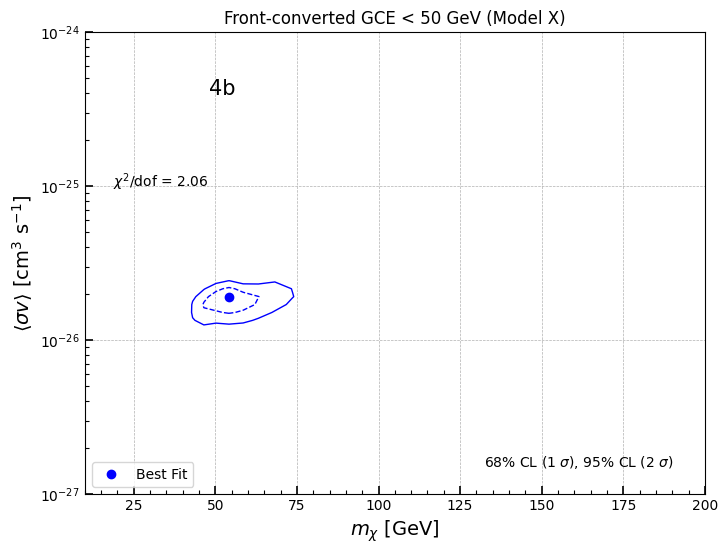

Processing: front, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_17_4b_16yr.png


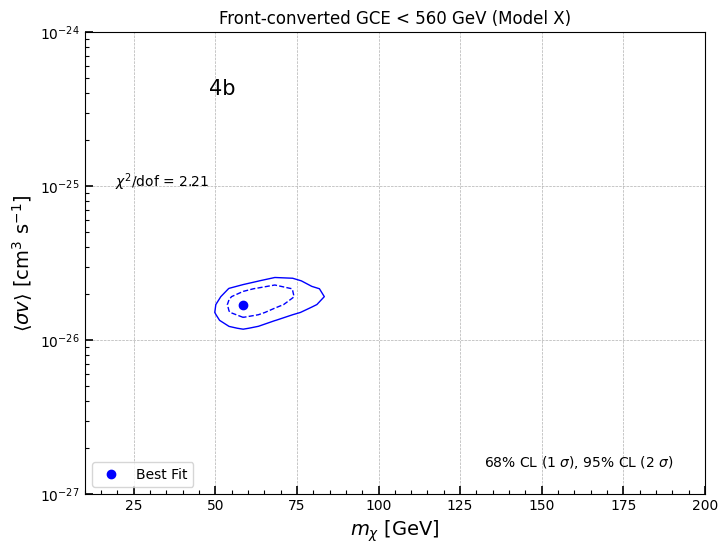

Processing: front_back, 14 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_14_4b_16yr.png


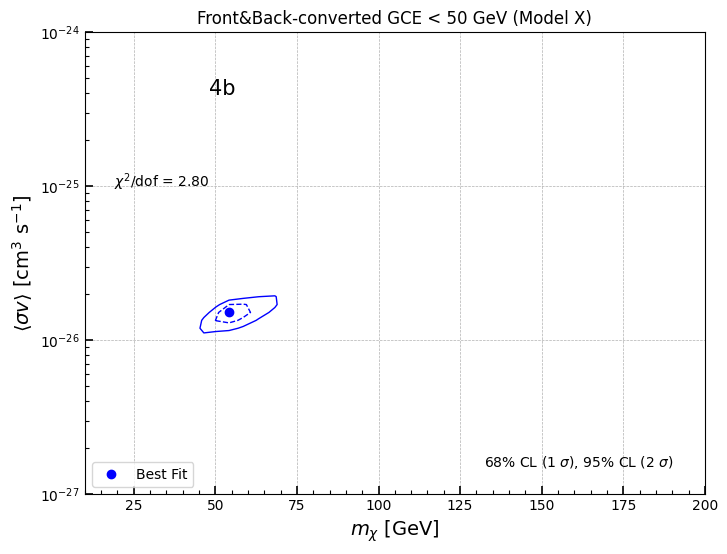

Processing: front_back, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_17_4b_16yr.png


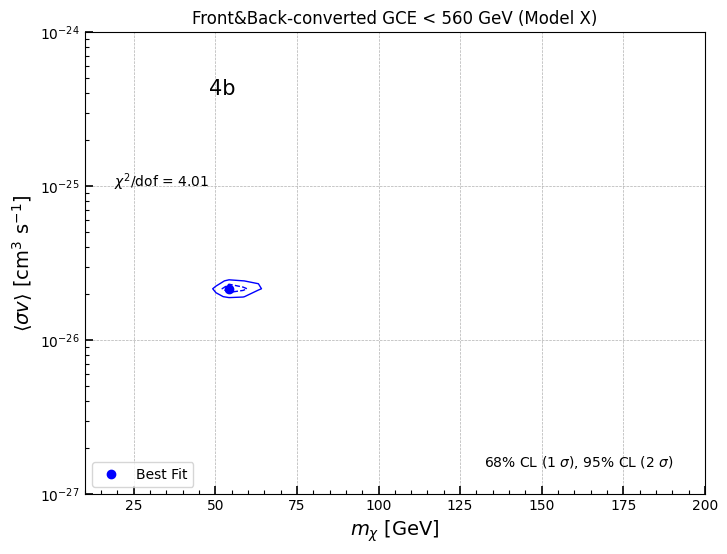

In [ ]:
#4b case chi-squared contour plot

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d
from iminuit import Minuit
import warnings
import os

base_data_path = './GCE_data/'
base_cov_path = './Cov/'
output_plot_dir = './GC_analysis/GCE_plots/'

os.makedirs(output_plot_dir, exist_ok=True)

channel_name = '4b'
mg5_base_dir = '/home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_sfdm_4b_r0.5/'

J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626

for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X']:
            
            print(f"Processing: {front}, {energy_bin_length} bins, Model {model}...")

            data_file = os.path.join(base_data_path, f'GCE_model_{model}_{front}_16yr_cholis.dat')
            
            try:
                g = np.loadtxt(data_file)
                
                bin_len = int(energy_bin_length)
                emeans = g[:bin_len, 0]
                GCE_data = g[:bin_len, 1]
                stat_unc = g[:bin_len, 2] 
                
            except Exception as e:
                print(f"⚠️ data load fail ({data_file}): {e}")
                continue

            try:
                cov_file_name = f"approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_{model}_16yr.npy"
                cov_path = os.path.join(base_cov_path, cov_file_name)
                
                if os.path.exists(cov_path):
                    cov_emp = np.load(cov_path)
                    cov_stat = np.diag(stat_unc**2)
                    cov_total = cov_stat + cov_emp
                    inv_cov = np.linalg.inv(cov_total)
                else:
                    print(f"⚠️ there is no file: {cov_file_name}.")
                    inv_cov = np.linalg.inv(np.diag(stat_unc**2))
                    
            except Exception as e:
                print(f"⚠️ error: {e}")
                continue

            def chi_square(dm_mass, sigmav):
                try:
                    interp = MG5Interpolator(dm_mass, channel_name, base_dir=mg5_base_dir)
                    e_model_raw, dNdE_model_raw = interp.interpolated_table()

                    func_interp = interp1d(e_model_raw, dNdE_model_raw, 
                                         fill_value=0, bounds_error=False, kind='linear')
                    
                    dNdE_interp = func_interp(emeans)
                    
                    model_flux = (emeans**2) * dNdE_interp * (sigmav / (dm_mass**2)) * J_FACTOR / SR

                    delta = model_flux - GCE_data
                    chi2_val = delta.T @ inv_cov @ delta
                    return chi2_val
                    
                except Exception:
                    return 1e9

            chi_square_vec = np.vectorize(chi_square)

            # ------------------------------------------
            # D. Grid Scan & Plotting
            # ------------------------------------------
            print(f"   scanning parameters...")

            sigmav_range = np.logspace(-27, -25, 40)
            mass_range = np.logspace(np.log10(10), np.log10(200), 40)
            
            DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

            chi2_values = chi_square_vec(DM_mass_grid, Sigmav_grid)

            min_idx = np.unravel_index(np.argmin(chi2_values), chi2_values.shape)
            best_mass = DM_mass_grid[min_idx]
            best_sigmav = Sigmav_grid[min_idx]
            min_chi2 = chi2_values[min_idx]
            
            dof = bin_len - 2 

            # Contour Levels
            levels = [min_chi2 + 2.30, min_chi2 + 6.18] # 1sigma, 2sigma

            plt.figure(figsize=(8, 6))
            
            # Contour
            CS = plt.contour(DM_mass_grid, Sigmav_grid, chi2_values, 
                        levels=levels, colors='blue', linestyles=['--', '-'], linewidths=1)
            
            # Best Fit Point
            plt.plot(best_mass, best_sigmav, 'bo', label=f'Best Fit')
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24) 
            
            # Ticks & Grid
            plt.tick_params(which='major', direction='in', length=6, width=1.2)
            plt.tick_params(which='minor', direction='in', length=3, width=0.8)
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {:.2f}'.format(min_chi2/dof), 
                     transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)

            plt.text(0.2, 0.90, r'4b', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)

            title_text = ""
            if front == 'front':
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front-converted GCE < {limit} GeV (Model X)'
            else:
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front&Back-converted GCE < {limit} GeV (Model X)'
            
            plt.title(title_text, fontsize=12)
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
            plt.legend(loc='lower left')

            save_name = f'GDE_model_{model}_{front}_E_{energy_bin_length}_{channel_name}_16yr.png'
            save_path = os.path.join(output_plot_dir, save_name)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"   Saved plot to: {save_path}")
            
            plt.show()

Processing: front, 14 bins, Model X...
   scanning parameters...
[4tau] data loading... (directory: /home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_sfdm_4tau_r0.5/)
✅ loading finish! (mass range: 11.0 ~ 1000.0 GeV, 100 files)
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_14_4tau_16yr.png


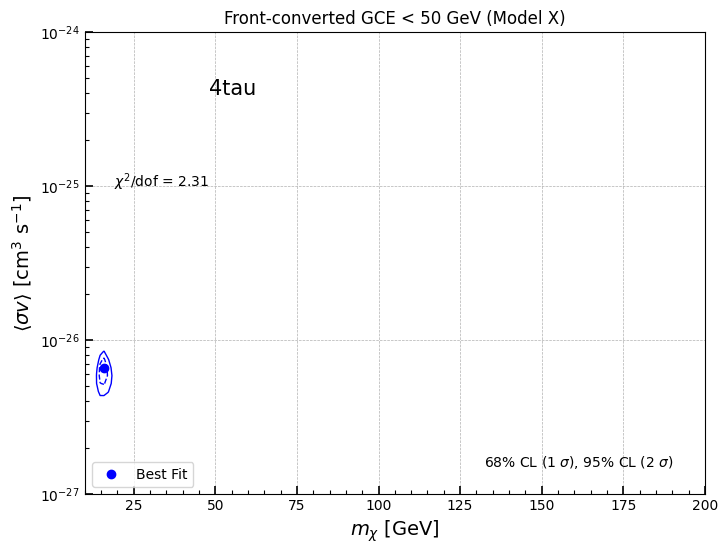

Processing: front, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_17_4tau_16yr.png


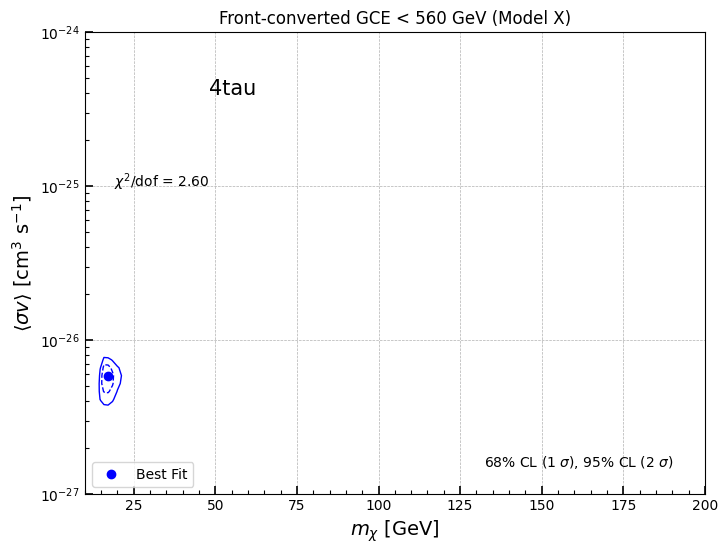

Processing: front_back, 14 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_14_4tau_16yr.png


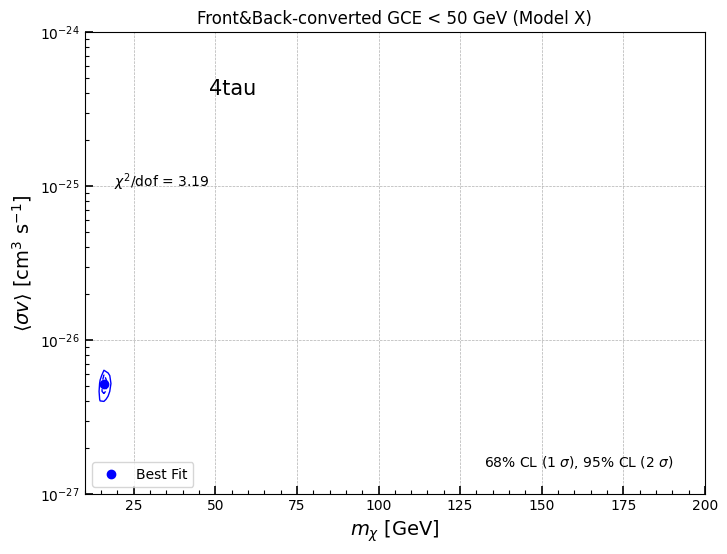

Processing: front_back, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_17_4tau_16yr.png


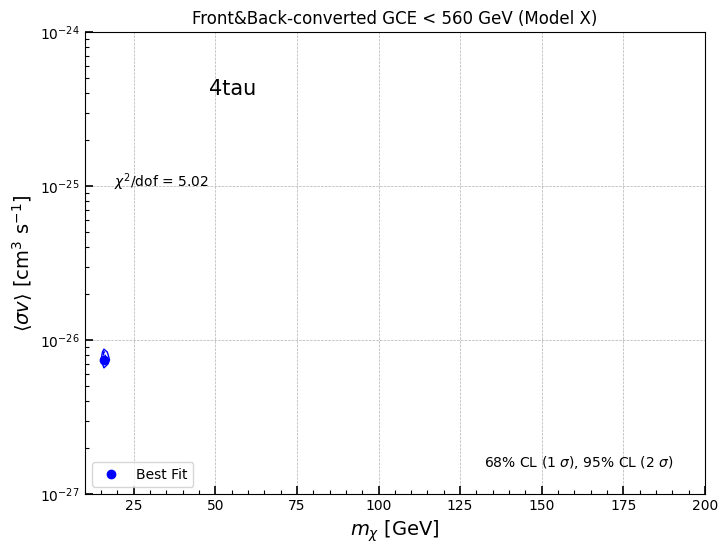

In [ ]:
#4tau case chi-squared contour plot

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d
from iminuit import Minuit
import warnings
import os

base_data_path = './GCE_data/'
base_cov_path = './Cov/'
output_plot_dir = './GC_analysis/GCE_plots/'

os.makedirs(output_plot_dir, exist_ok=True)

channel_name = '4tau'
mg5_base_dir = '/home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_sfdm_4tau_r0.5/'

J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626

for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X']:
            
            print(f"Processing: {front}, {energy_bin_length} bins, Model {model}...")

            data_file = os.path.join(base_data_path, f'GCE_model_{model}_{front}_16yr_cholis.dat')
            
            try:
                g = np.loadtxt(data_file)
                
                bin_len = int(energy_bin_length)
                emeans = g[:bin_len, 0]
                GCE_data = g[:bin_len, 1]
                stat_unc = g[:bin_len, 2] 
                
            except Exception as e:
                print(f"⚠️ data load fail ({data_file}): {e}")
                continue

            try:
                cov_file_name = f"approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_{model}_16yr.npy"
                cov_path = os.path.join(base_cov_path, cov_file_name)
                
                if os.path.exists(cov_path):
                    cov_emp = np.load(cov_path)
                    cov_stat = np.diag(stat_unc**2)
                    cov_total = cov_stat + cov_emp
                    inv_cov = np.linalg.inv(cov_total)
                else:
                    print(f"⚠️ there is no file: {cov_file_name}.")
                    inv_cov = np.linalg.inv(np.diag(stat_unc**2))
                    
            except Exception as e:
                print(f"⚠️ error: {e}")
                continue

            def chi_square(dm_mass, sigmav):
                try:
                    interp = MG5Interpolator(dm_mass, channel_name, base_dir=mg5_base_dir)
                    e_model_raw, dNdE_model_raw = interp.interpolated_table()

                    func_interp = interp1d(e_model_raw, dNdE_model_raw, 
                                         fill_value=0, bounds_error=False, kind='linear')
                    
                    dNdE_interp = func_interp(emeans)
                    
                    model_flux = (emeans**2) * dNdE_interp * (sigmav / (dm_mass**2)) * J_FACTOR / SR

                    delta = model_flux - GCE_data
                    chi2_val = delta.T @ inv_cov @ delta
                    return chi2_val
                    
                except Exception:
                    return 1e9

            chi_square_vec = np.vectorize(chi_square)

            # ------------------------------------------
            # D. Grid Scan & Plotting
            # ------------------------------------------
            print(f"   scanning parameters...")

            sigmav_range = np.logspace(-27, -25, 40)
            mass_range = np.logspace(np.log10(10), np.log10(200), 40)
            
            DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

            chi2_values = chi_square_vec(DM_mass_grid, Sigmav_grid)

            min_idx = np.unravel_index(np.argmin(chi2_values), chi2_values.shape)
            best_mass = DM_mass_grid[min_idx]
            best_sigmav = Sigmav_grid[min_idx]
            min_chi2 = chi2_values[min_idx]
            
            dof = bin_len - 2 

            # Contour Levels
            levels = [min_chi2 + 2.30, min_chi2 + 6.18] # 1sigma, 2sigma

            plt.figure(figsize=(8, 6))
            
            # Contour
            CS = plt.contour(DM_mass_grid, Sigmav_grid, chi2_values, 
                        levels=levels, colors='blue', linestyles=['--', '-'], linewidths=1)
            
            # Best Fit Point
            plt.plot(best_mass, best_sigmav, 'bo', label=f'Best Fit')
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24) 
            
            # Ticks & Grid
            plt.tick_params(which='major', direction='in', length=6, width=1.2)
            plt.tick_params(which='minor', direction='in', length=3, width=0.8)
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {:.2f}'.format(min_chi2/dof), 
                     transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)

            plt.text(0.2, 0.90, r'4tau', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)

            title_text = ""
            if front == 'front':
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front-converted GCE < {limit} GeV (Model X)'
            else:
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front&Back-converted GCE < {limit} GeV (Model X)'
            
            plt.title(title_text, fontsize=12)
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
            plt.legend(loc='lower left')

            save_name = f'GDE_model_{model}_{front}_E_{energy_bin_length}_{channel_name}_16yr.png'
            save_path = os.path.join(output_plot_dir, save_name)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"   Saved plot to: {save_path}")
            
            plt.show()

Processing: front, 14 bins, Model X...
   scanning parameters...
[2b2tau] data loading... (directory: /home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_sfdm_2b2tau_r0.5/)
✅ loading finish! (mass range: 19.0 ~ 1000.0 GeV, 88 files)
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_14_2b2tau_16yr.png


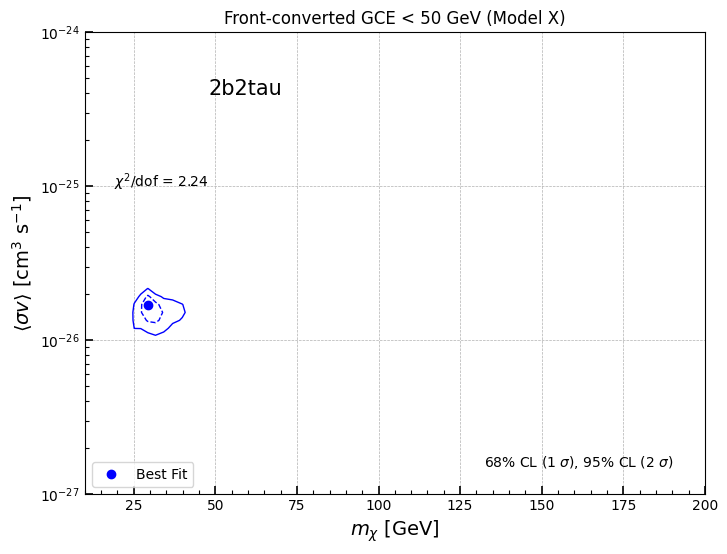

Processing: front, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_17_2b2tau_16yr.png


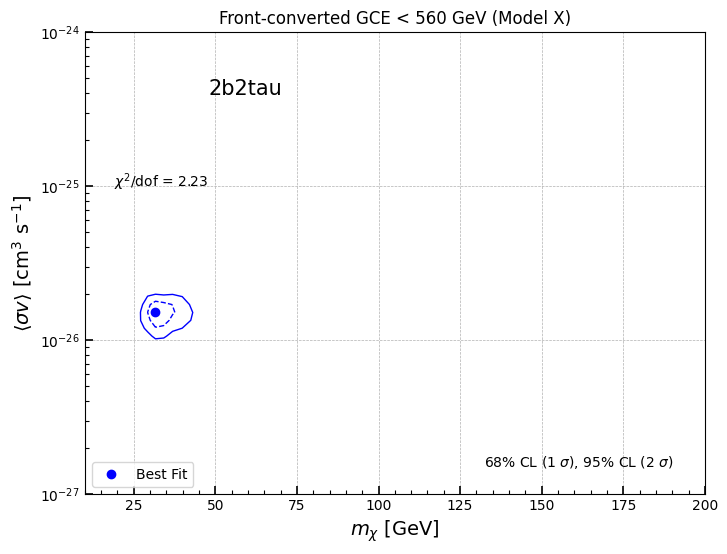

Processing: front_back, 14 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_14_2b2tau_16yr.png


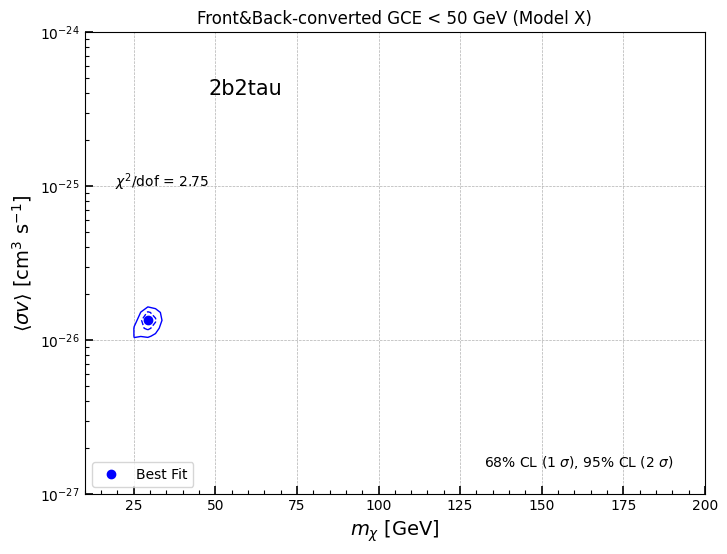

Processing: front_back, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_17_2b2tau_16yr.png


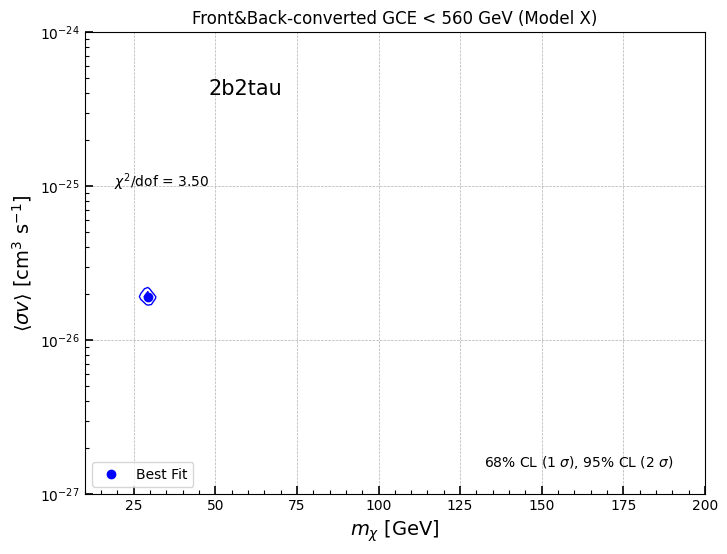

In [ ]:
#2b2tau case chi-squared contour plot

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d
from iminuit import Minuit
import warnings
import os

base_data_path = './GCE_data/'
base_cov_path = './Cov/'
output_plot_dir = './GC_analysis/GCE_plots/'

os.makedirs(output_plot_dir, exist_ok=True)

channel_name = '2b2tau'
mg5_base_dir = '/home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_sfdm_2b2tau_r0.5/'

J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626

for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X']:
            
            print(f"Processing: {front}, {energy_bin_length} bins, Model {model}...")

            data_file = os.path.join(base_data_path, f'GCE_model_{model}_{front}_16yr_cholis.dat')
            
            try:
                g = np.loadtxt(data_file)
                
                bin_len = int(energy_bin_length)
                emeans = g[:bin_len, 0]
                GCE_data = g[:bin_len, 1]
                stat_unc = g[:bin_len, 2] 
                
            except Exception as e:
                print(f"⚠️ data load fail ({data_file}): {e}")
                continue

            try:
                cov_file_name = f"approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_{model}_16yr.npy"
                cov_path = os.path.join(base_cov_path, cov_file_name)
                
                if os.path.exists(cov_path):
                    cov_emp = np.load(cov_path)
                    cov_stat = np.diag(stat_unc**2)
                    cov_total = cov_stat + cov_emp
                    inv_cov = np.linalg.inv(cov_total)
                else:
                    print(f"⚠️ there is no file: {cov_file_name}.")
                    inv_cov = np.linalg.inv(np.diag(stat_unc**2))
                    
            except Exception as e:
                print(f"⚠️ error: {e}")
                continue

            def chi_square(dm_mass, sigmav):
                try:
                    interp = MG5Interpolator(dm_mass, channel_name, base_dir=mg5_base_dir)
                    e_model_raw, dNdE_model_raw = interp.interpolated_table()

                    func_interp = interp1d(e_model_raw, dNdE_model_raw, 
                                         fill_value=0, bounds_error=False, kind='linear')
                    
                    dNdE_interp = func_interp(emeans)
                    
                    model_flux = (emeans**2) * dNdE_interp * (sigmav / (dm_mass**2)) * J_FACTOR / SR

                    delta = model_flux - GCE_data
                    chi2_val = delta.T @ inv_cov @ delta
                    return chi2_val
                    
                except Exception:
                    return 1e9

            chi_square_vec = np.vectorize(chi_square)

            # ------------------------------------------
            # D. Grid Scan & Plotting
            # ------------------------------------------
            print(f"   scanning parameters...")

            sigmav_range = np.logspace(-27, -25, 40)
            mass_range = np.logspace(np.log10(10), np.log10(200), 40)
            
            DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

            chi2_values = chi_square_vec(DM_mass_grid, Sigmav_grid)

            min_idx = np.unravel_index(np.argmin(chi2_values), chi2_values.shape)
            best_mass = DM_mass_grid[min_idx]
            best_sigmav = Sigmav_grid[min_idx]
            min_chi2 = chi2_values[min_idx]
            
            dof = bin_len - 2 

            # Contour Levels
            levels = [min_chi2 + 2.30, min_chi2 + 6.18] # 1sigma, 2sigma

            plt.figure(figsize=(8, 6))
            
            # Contour
            CS = plt.contour(DM_mass_grid, Sigmav_grid, chi2_values, 
                        levels=levels, colors='blue', linestyles=['--', '-'], linewidths=1)
            
            # Best Fit Point
            plt.plot(best_mass, best_sigmav, 'bo', label=f'Best Fit')
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24) 
            
            # Ticks & Grid
            plt.tick_params(which='major', direction='in', length=6, width=1.2)
            plt.tick_params(which='minor', direction='in', length=3, width=0.8)
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {:.2f}'.format(min_chi2/dof), 
                     transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)

            plt.text(0.2, 0.90, r'2b2tau', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)

            title_text = ""
            if front == 'front':
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front-converted GCE < {limit} GeV (Model X)'
            else:
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front&Back-converted GCE < {limit} GeV (Model X)'
            
            plt.title(title_text, fontsize=12)
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
            plt.legend(loc='lower left')

            save_name = f'GDE_model_{model}_{front}_E_{energy_bin_length}_{channel_name}_16yr.png'
            save_path = os.path.join(output_plot_dir, save_name)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"   Saved plot to: {save_path}")
            
            plt.show()

Processing: front, 14 bins, Model X...
   scanning parameters...
[4b] data loading... (directory: /home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_sfdm_4b_r0.3/)
✅ loading finish! (mass range: 32.8 ~ 1000.0 GeV, 76 files)
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_14_4b_16yr.png


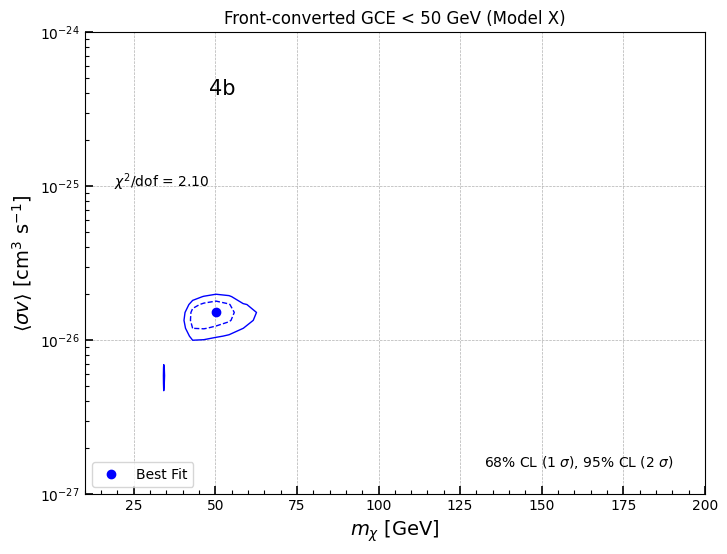

Processing: front, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_17_4b_16yr.png


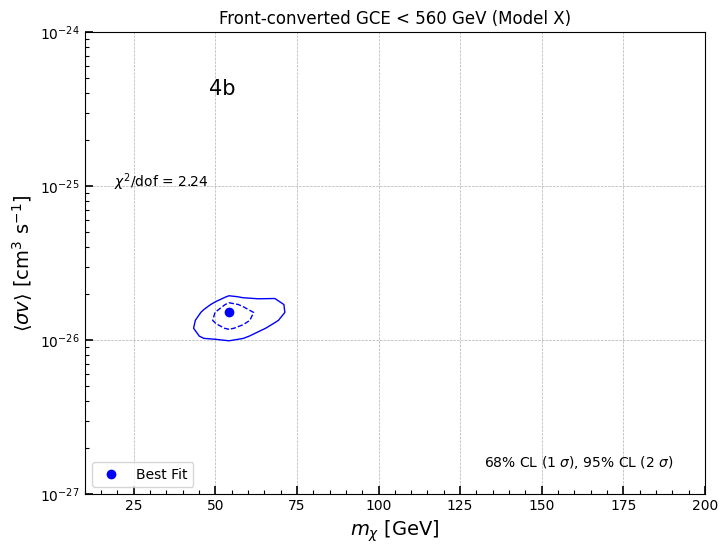

Processing: front_back, 14 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_14_4b_16yr.png


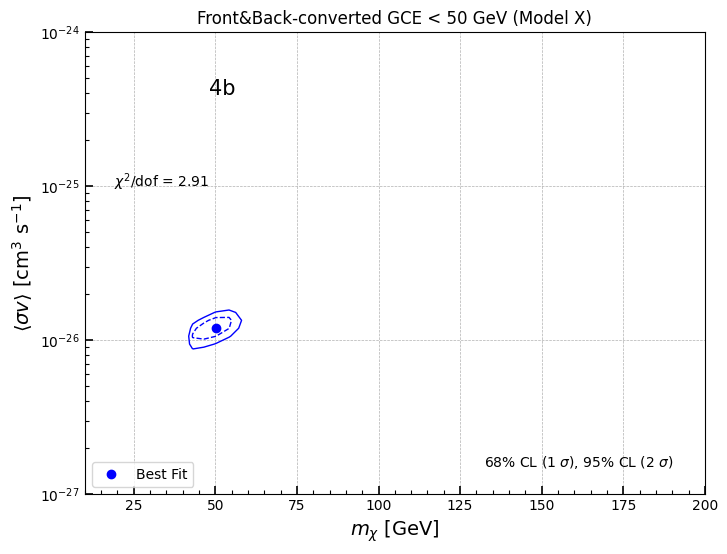

Processing: front_back, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_17_4b_16yr.png


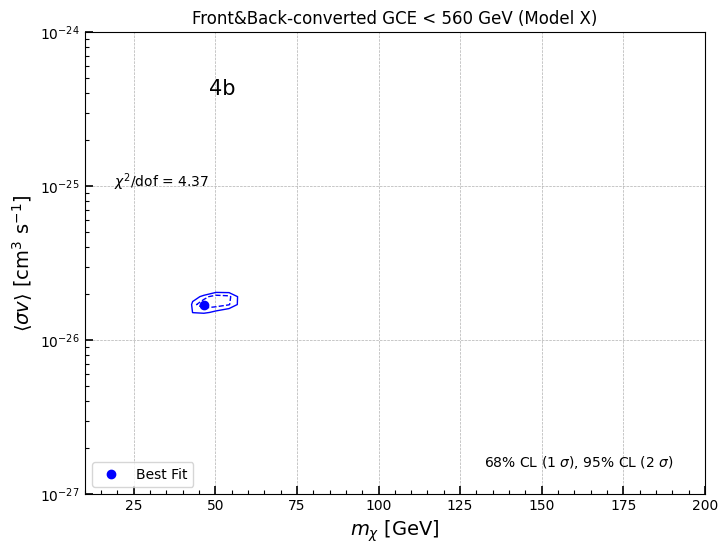

In [11]:
#4b case chi-squared contour plot for r0.3

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d
from iminuit import Minuit
import warnings
import os

base_data_path = './GCE_data/'
base_cov_path = './Cov/'
output_plot_dir = './GC_analysis/GCE_plots/'

os.makedirs(output_plot_dir, exist_ok=True)

channel_name = '4b'
mg5_base_dir = '/home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_sfdm_4b_r0.3/'

J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626

for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X']:
            
            print(f"Processing: {front}, {energy_bin_length} bins, Model {model}...")

            data_file = os.path.join(base_data_path, f'GCE_model_{model}_{front}_16yr_cholis.dat')
            
            try:
                g = np.loadtxt(data_file)
                
                bin_len = int(energy_bin_length)
                emeans = g[:bin_len, 0]
                GCE_data = g[:bin_len, 1]
                stat_unc = g[:bin_len, 2] 
                
            except Exception as e:
                print(f"⚠️ data load fail ({data_file}): {e}")
                continue

            try:
                cov_file_name = f"approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_{model}_16yr.npy"
                cov_path = os.path.join(base_cov_path, cov_file_name)
                
                if os.path.exists(cov_path):
                    cov_emp = np.load(cov_path)
                    cov_stat = np.diag(stat_unc**2)
                    cov_total = cov_stat + cov_emp
                    inv_cov = np.linalg.inv(cov_total)
                else:
                    print(f"⚠️ there is no file: {cov_file_name}.")
                    inv_cov = np.linalg.inv(np.diag(stat_unc**2))
                    
            except Exception as e:
                print(f"⚠️ error: {e}")
                continue

            def chi_square(dm_mass, sigmav):
                try:
                    interp = MG5Interpolator(dm_mass, channel_name, base_dir=mg5_base_dir)
                    e_model_raw, dNdE_model_raw = interp.interpolated_table()

                    func_interp = interp1d(e_model_raw, dNdE_model_raw, 
                                         fill_value=0, bounds_error=False, kind='linear')
                    
                    dNdE_interp = func_interp(emeans)
                    
                    model_flux = (emeans**2) * dNdE_interp * (sigmav / (dm_mass**2)) * J_FACTOR / SR

                    delta = model_flux - GCE_data
                    chi2_val = delta.T @ inv_cov @ delta
                    return chi2_val
                    
                except Exception:
                    return 1e9

            chi_square_vec = np.vectorize(chi_square)

            # ------------------------------------------
            # D. Grid Scan & Plotting
            # ------------------------------------------
            print(f"   scanning parameters...")

            sigmav_range = np.logspace(-27, -25, 40)
            mass_range = np.logspace(np.log10(10), np.log10(200), 40)
            
            DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

            chi2_values = chi_square_vec(DM_mass_grid, Sigmav_grid)

            min_idx = np.unravel_index(np.argmin(chi2_values), chi2_values.shape)
            best_mass = DM_mass_grid[min_idx]
            best_sigmav = Sigmav_grid[min_idx]
            min_chi2 = chi2_values[min_idx]
            
            dof = bin_len - 2 

            # Contour Levels
            levels = [min_chi2 + 2.30, min_chi2 + 6.18] # 1sigma, 2sigma

            plt.figure(figsize=(8, 6))
            
            # Contour
            CS = plt.contour(DM_mass_grid, Sigmav_grid, chi2_values, 
                        levels=levels, colors='blue', linestyles=['--', '-'], linewidths=1)
            
            # Best Fit Point
            plt.plot(best_mass, best_sigmav, 'bo', label=f'Best Fit')
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24) 
            
            # Ticks & Grid
            plt.tick_params(which='major', direction='in', length=6, width=1.2)
            plt.tick_params(which='minor', direction='in', length=3, width=0.8)
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {:.2f}'.format(min_chi2/dof), 
                     transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)

            plt.text(0.2, 0.90, r'4b', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)

            title_text = ""
            if front == 'front':
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front-converted GCE < {limit} GeV (Model X)'
            else:
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front&Back-converted GCE < {limit} GeV (Model X)'
            
            plt.title(title_text, fontsize=12)
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
            plt.legend(loc='lower left')

            save_name = f'GDE_model_{model}_{front}_E_{energy_bin_length}_{channel_name}_16yr.png'
            save_path = os.path.join(output_plot_dir, save_name)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"   Saved plot to: {save_path}")
            
            plt.show()

Processing: front, 14 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_14_4b_16yr.png


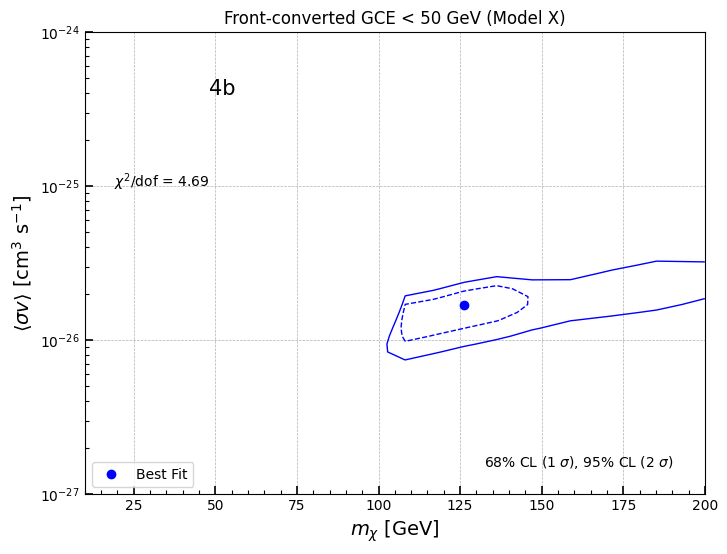

Processing: front, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_17_4b_16yr.png


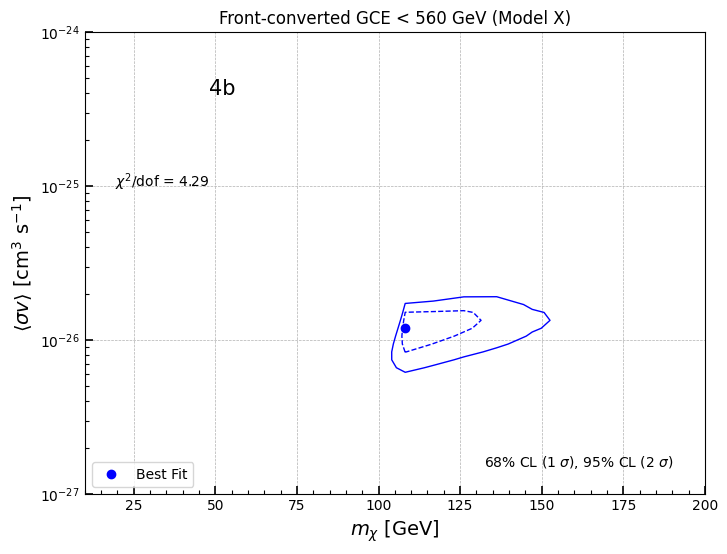

Processing: front_back, 14 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_14_4b_16yr.png


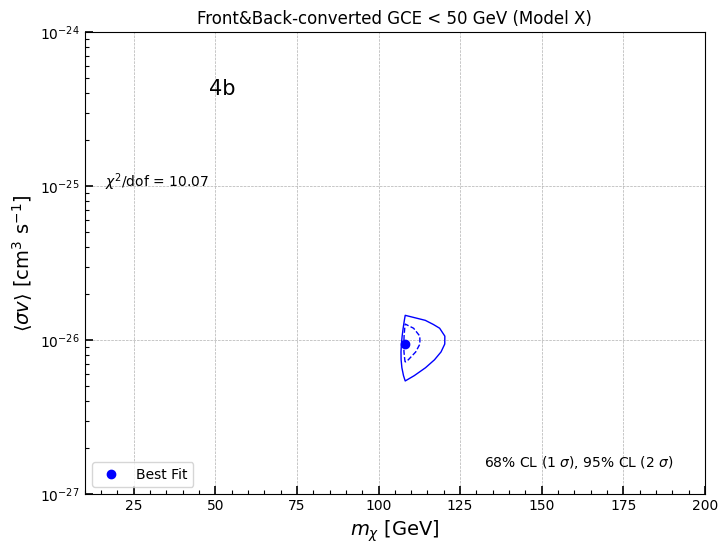

Processing: front_back, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_17_4b_16yr.png


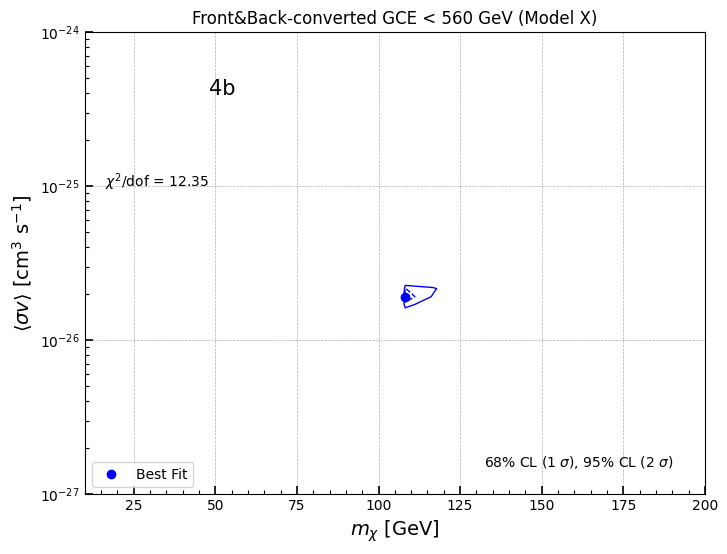

In [6]:
#4b case chi-squared contour plot for r0.1

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d
from iminuit import Minuit
import warnings
import os

base_data_path = './GCE_data/'
base_cov_path = './Cov/'
output_plot_dir = './GC_analysis/GCE_plots/'

os.makedirs(output_plot_dir, exist_ok=True)

channel_name = '4b'
mg5_base_dir = '/home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_sfdm_4b_r0.1/'

J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626

for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X']:
            
            print(f"Processing: {front}, {energy_bin_length} bins, Model {model}...")

            data_file = os.path.join(base_data_path, f'GCE_model_{model}_{front}_16yr_cholis.dat')
            
            try:
                g = np.loadtxt(data_file)
                
                bin_len = int(energy_bin_length)
                emeans = g[:bin_len, 0]
                GCE_data = g[:bin_len, 1]
                stat_unc = g[:bin_len, 2] 
                
            except Exception as e:
                print(f"⚠️ data load fail ({data_file}): {e}")
                continue

            try:
                cov_file_name = f"approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_{model}_16yr.npy"
                cov_path = os.path.join(base_cov_path, cov_file_name)
                
                if os.path.exists(cov_path):
                    cov_emp = np.load(cov_path)
                    cov_stat = np.diag(stat_unc**2)
                    cov_total = cov_stat + cov_emp
                    inv_cov = np.linalg.inv(cov_total)
                else:
                    print(f"⚠️ there is no file: {cov_file_name}.")
                    inv_cov = np.linalg.inv(np.diag(stat_unc**2))
                    
            except Exception as e:
                print(f"⚠️ error: {e}")
                continue

            def chi_square(dm_mass, sigmav):
                try:
                    interp = MG5Interpolator(dm_mass, channel_name, base_dir=mg5_base_dir)
                    e_model_raw, dNdE_model_raw = interp.interpolated_table()

                    func_interp = interp1d(e_model_raw, dNdE_model_raw, 
                                         fill_value=0, bounds_error=False, kind='linear')
                    
                    dNdE_interp = func_interp(emeans)
                    
                    model_flux = (emeans**2) * dNdE_interp * (sigmav / (dm_mass**2)) * J_FACTOR / SR

                    delta = model_flux - GCE_data
                    chi2_val = delta.T @ inv_cov @ delta
                    return chi2_val
                    
                except Exception:
                    return 1e9

            chi_square_vec = np.vectorize(chi_square)

            # ------------------------------------------
            # D. Grid Scan & Plotting
            # ------------------------------------------
            print(f"   scanning parameters...")

            sigmav_range = np.logspace(-27, -25, 40)
            mass_range = np.logspace(np.log10(10), np.log10(200), 40)
            
            DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

            chi2_values = chi_square_vec(DM_mass_grid, Sigmav_grid)

            min_idx = np.unravel_index(np.argmin(chi2_values), chi2_values.shape)
            best_mass = DM_mass_grid[min_idx]
            best_sigmav = Sigmav_grid[min_idx]
            min_chi2 = chi2_values[min_idx]
            
            dof = bin_len - 2 

            # Contour Levels
            levels = [min_chi2 + 2.30, min_chi2 + 6.18] # 1sigma, 2sigma

            plt.figure(figsize=(8, 6))
            
            # Contour
            CS = plt.contour(DM_mass_grid, Sigmav_grid, chi2_values, 
                        levels=levels, colors='blue', linestyles=['--', '-'], linewidths=1)
            
            # Best Fit Point
            plt.plot(best_mass, best_sigmav, 'bo', label=f'Best Fit')
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24) 
            
            # Ticks & Grid
            plt.tick_params(which='major', direction='in', length=6, width=1.2)
            plt.tick_params(which='minor', direction='in', length=3, width=0.8)
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {:.2f}'.format(min_chi2/dof), 
                     transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)

            plt.text(0.2, 0.90, r'4b', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)

            title_text = ""
            if front == 'front':
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front-converted GCE < {limit} GeV (Model X)'
            else:
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front&Back-converted GCE < {limit} GeV (Model X)'
            
            plt.title(title_text, fontsize=12)
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
            plt.legend(loc='lower left')

            save_name = f'GDE_model_{model}_{front}_E_{energy_bin_length}_{channel_name}_16yr.png'
            save_path = os.path.join(output_plot_dir, save_name)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"   Saved plot to: {save_path}")
            
            plt.show()

Processing: front, 14 bins, Model X...
   scanning parameters...
[4b] data loading... (directory: /home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_sfdm_4b_r0.5/)
✅ loading finish! (mass range: 19.0 ~ 1000.0 GeV, 88 files)
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_14_4b_16yr.png


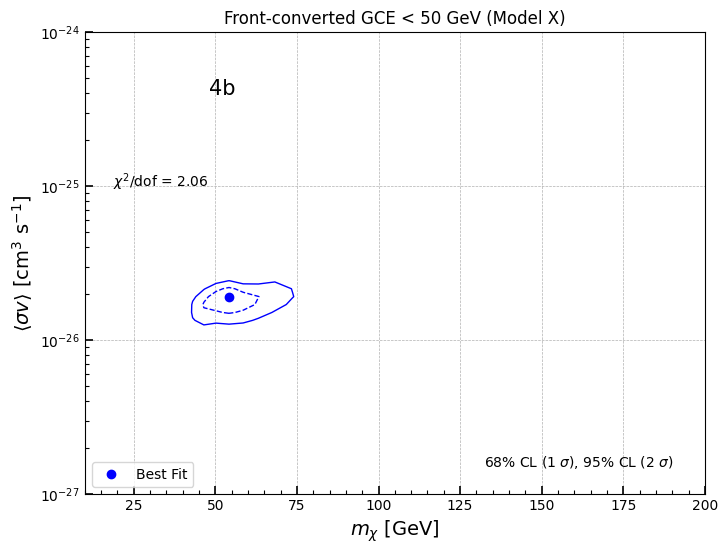

Processing: front, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_E_17_4b_16yr.png


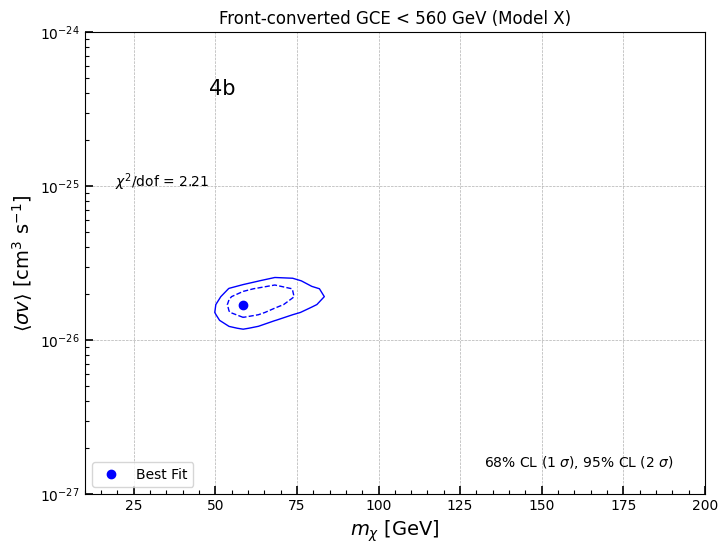

Processing: front_back, 14 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_14_4b_16yr.png


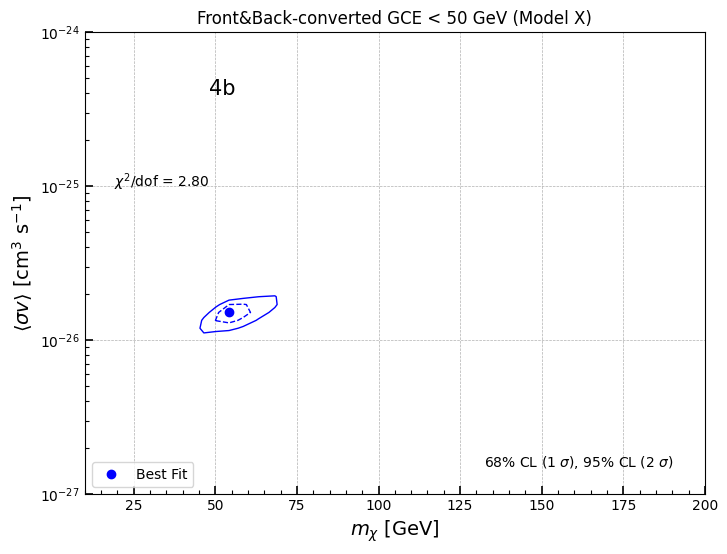

Processing: front_back, 17 bins, Model X...
   scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/GDE_model_X_front_back_E_17_4b_16yr.png


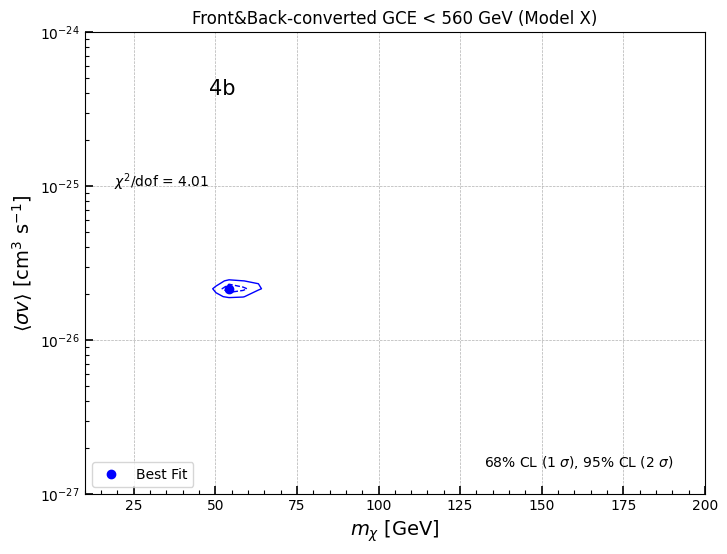

In [7]:
#4b case chi-squared contour plot for r0.5

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d
from iminuit import Minuit
import warnings
import os

base_data_path = './GCE_data/'
base_cov_path = './Cov/'
output_plot_dir = './GC_analysis/GCE_plots/'

os.makedirs(output_plot_dir, exist_ok=True)

channel_name = '4b'
mg5_base_dir = '/home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_sfdm_4b_r0.5/'

J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626

for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X']:
            
            print(f"Processing: {front}, {energy_bin_length} bins, Model {model}...")

            data_file = os.path.join(base_data_path, f'GCE_model_{model}_{front}_16yr_cholis.dat')
            
            try:
                g = np.loadtxt(data_file)
                
                bin_len = int(energy_bin_length)
                emeans = g[:bin_len, 0]
                GCE_data = g[:bin_len, 1]
                stat_unc = g[:bin_len, 2] 
                
            except Exception as e:
                print(f"⚠️ data load fail ({data_file}): {e}")
                continue

            try:
                cov_file_name = f"approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_{model}_16yr.npy"
                cov_path = os.path.join(base_cov_path, cov_file_name)
                
                if os.path.exists(cov_path):
                    cov_emp = np.load(cov_path)
                    cov_stat = np.diag(stat_unc**2)
                    cov_total = cov_stat + cov_emp
                    inv_cov = np.linalg.inv(cov_total)
                else:
                    print(f"⚠️ there is no file: {cov_file_name}.")
                    inv_cov = np.linalg.inv(np.diag(stat_unc**2))
                    
            except Exception as e:
                print(f"⚠️ error: {e}")
                continue

            def chi_square(dm_mass, sigmav):
                try:
                    interp = MG5Interpolator(dm_mass, channel_name, base_dir=mg5_base_dir)
                    e_model_raw, dNdE_model_raw = interp.interpolated_table()

                    func_interp = interp1d(e_model_raw, dNdE_model_raw, 
                                         fill_value=0, bounds_error=False, kind='linear')
                    
                    dNdE_interp = func_interp(emeans)
                    
                    model_flux = (emeans**2) * dNdE_interp * (sigmav / (dm_mass**2)) * J_FACTOR / SR

                    delta = model_flux - GCE_data
                    chi2_val = delta.T @ inv_cov @ delta
                    return chi2_val
                    
                except Exception:
                    return 1e9

            chi_square_vec = np.vectorize(chi_square)

            # ------------------------------------------
            # D. Grid Scan & Plotting
            # ------------------------------------------
            print(f"   scanning parameters...")

            sigmav_range = np.logspace(-27, -25, 40)
            mass_range = np.logspace(np.log10(10), np.log10(200), 40)
            
            DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

            chi2_values = chi_square_vec(DM_mass_grid, Sigmav_grid)

            min_idx = np.unravel_index(np.argmin(chi2_values), chi2_values.shape)
            best_mass = DM_mass_grid[min_idx]
            best_sigmav = Sigmav_grid[min_idx]
            min_chi2 = chi2_values[min_idx]
            
            dof = bin_len - 2 

            # Contour Levels
            levels = [min_chi2 + 2.30, min_chi2 + 6.18] # 1sigma, 2sigma

            plt.figure(figsize=(8, 6))
            
            # Contour
            CS = plt.contour(DM_mass_grid, Sigmav_grid, chi2_values, 
                        levels=levels, colors='blue', linestyles=['--', '-'], linewidths=1)
            
            # Best Fit Point
            plt.plot(best_mass, best_sigmav, 'bo', label=f'Best Fit')
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24) 
            
            # Ticks & Grid
            plt.tick_params(which='major', direction='in', length=6, width=1.2)
            plt.tick_params(which='minor', direction='in', length=3, width=0.8)
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {:.2f}'.format(min_chi2/dof), 
                     transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)

            plt.text(0.2, 0.90, r'4b', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)

            title_text = ""
            if front == 'front':
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front-converted GCE < {limit} GeV (Model X)'
            else:
                limit = "50" if energy_bin_length == '14' else "560"
                title_text = f'Front&Back-converted GCE < {limit} GeV (Model X)'
            
            plt.title(title_text, fontsize=12)
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)
            plt.legend(loc='lower left')

            save_name = f'GDE_model_{model}_{front}_E_{energy_bin_length}_{channel_name}_16yr.png'
            save_path = os.path.join(output_plot_dir, save_name)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"   Saved plot to: {save_path}")
            
            plt.show()

## Refind Best-fit model

✅ data load success!


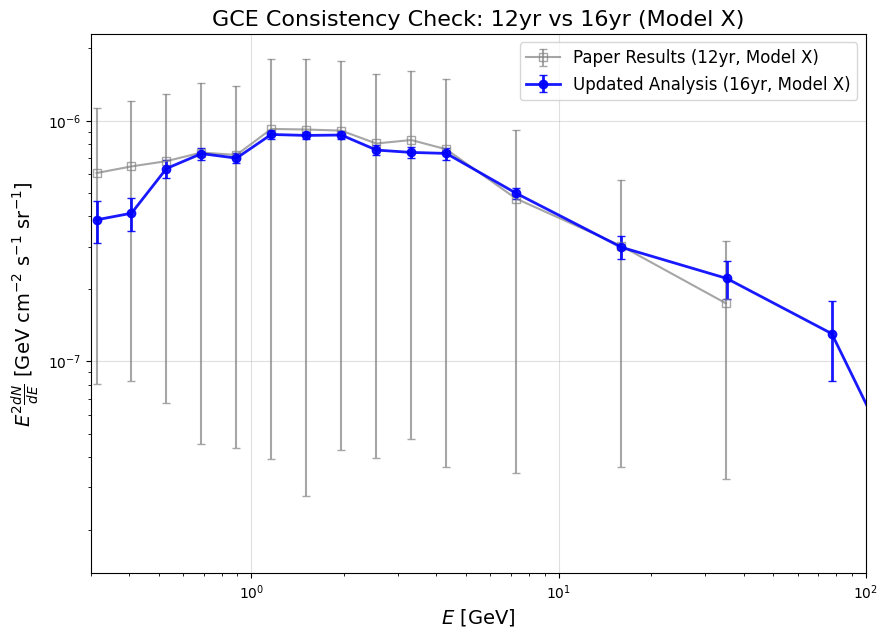

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os

path_12yr_dir = './GCE_TEMPLATES_FILES_v3/Figures_12_and_14_GCE_Spectra/'
file_12yr = os.path.join(path_12yr_dir, 'GCE_ModelX_flux_Inner40x40_masked_disk.dat')

path_16yr_file = './GCE_data/GCE_model_X_front_16yr_cholis.dat'

try:
    d12 = np.loadtxt(file_12yr)
    E_12 = d12[:, 0]
    Flux_12 = d12[:, 1]

    if d12.shape[1] >= 3:
        Err_12 = d12[:, 2] 
    else:
        Err_12 = np.zeros_like(Flux_12) 

    d16 = np.loadtxt(path_16yr_file)
    E_16 = d16[:, 0]
    Flux_16 = d16[:, 1]
    if d16.shape[1] >= 3:
        Err_16 = d16[:, 2]
    else:
        Err_16 = np.zeros_like(Flux_16)

    print("✅ data load success!")

except Exception as e:
    print(f"❌ error: {e}")
    if os.path.exists(path_12yr_dir):
        print(f"example in folder: {os.listdir(path_12yr_dir)[:3]}")
    else:
        print("data directory is not correct.")
    raise

plt.figure(figsize=(10, 7))

# 12yr Data (Model X)
plt.errorbar(E_12, Flux_12, yerr=Err_12, 
             fmt='s-', color='gray', mfc='none', mec='gray', capsize=3, alpha=0.7,
             label='Paper Results (12yr, Model X)')

# 16yr Data (Model X)
plt.errorbar(E_16, Flux_16, yerr=Err_16, 
             fmt='o-', color='blue', linewidth=2, capsize=3, alpha=0.9,
             label='Updated Analysis (16yr, Model X)')


plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$E$ [GeV]', fontsize=14)
plt.ylabel(r'$E^2 \frac{dN}{dE}$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=14)
plt.title('GCE Consistency Check: 12yr vs 16yr (Model X)', fontsize=16)
#plt.ylim(1e-7, 1e-5) 
plt.xlim(0.3, 100)
plt.legend(fontsize=12)
plt.grid(True, which='major', alpha=0.4)

plt.show()

Plotting 15 background models...


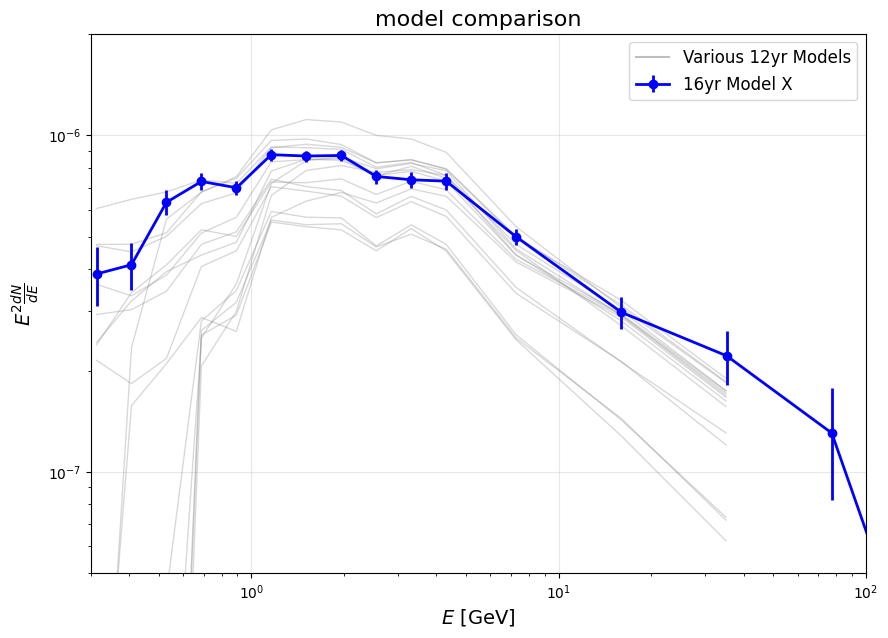

In [9]:
import glob

plt.figure(figsize=(10, 7))

all_files = glob.glob(os.path.join(path_12yr_dir, 'GCE_Model*_flux_Inner40x40_masked_disk.dat'))
selected_files = all_files[:15] 

print(f"Plotting {len(selected_files)} background models...")

for f in selected_files:
    try:
        d = np.loadtxt(f)
        fname = os.path.basename(f)
        model_name = fname.split('_')[1] 
        
        plt.plot(d[:, 0], d[:, 1], color='gray', alpha=0.3, linewidth=1)
    except:
        pass

plt.errorbar(E_16, Flux_16, yerr=Err_16, 
             fmt='o-', color='blue', linewidth=2, label='16yr Model X')

plt.plot([], [], color='gray', alpha=0.5, label='Various 12yr Models')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5e-8, 2e-6)
plt.xlim(0.3, 100)
plt.xlabel(r'$E$ [GeV]', fontsize=14)
plt.ylabel(r'$E^2 \frac{dN}{dE}$', fontsize=14)
plt.title('model comparison', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

총 85개의 GDE 모델 데이터를 분석합니다...



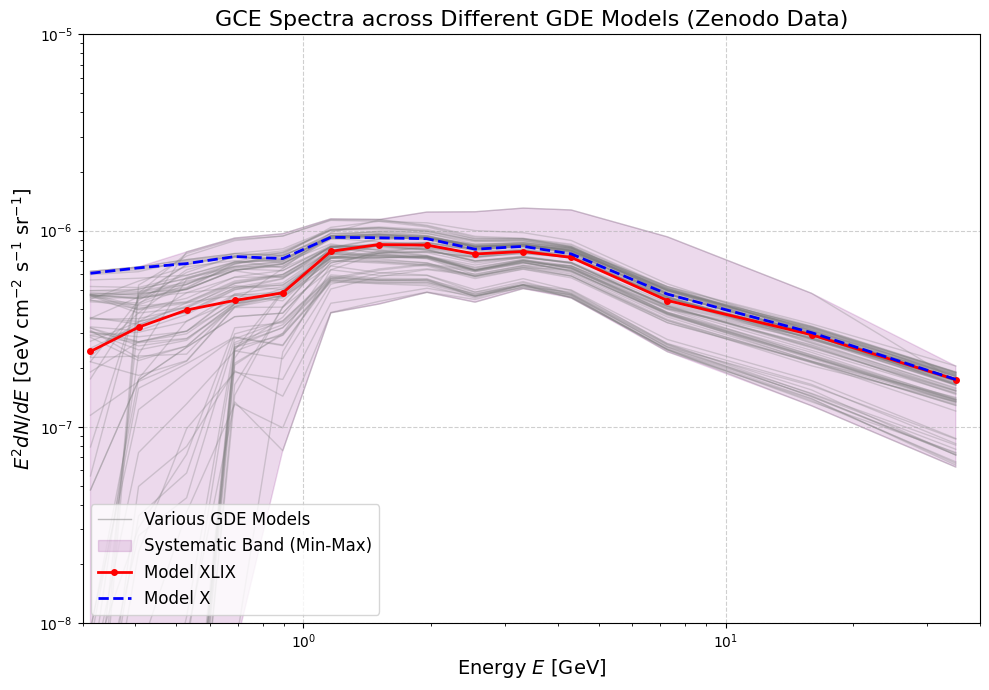

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ==============================================================================
# 1. 경로 및 파일 설정
# ==============================================================================
# 사용자님의 서버 내 데이터 경로
data_dir = '/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/Figures_12_and_14_GCE_Spectra/'

# 해당 폴더 내의 모든 Inner40x40 (North/South 제외, 전체 디스크 기준) 파일 불러오기
# (필요에 따라 패턴을 수정하여 North나 South만 분석할 수도 있습니다)
file_pattern = os.path.join(data_dir, '*_flux_Inner40x40_masked_disk.dat')
file_list = glob.glob(file_pattern)

# 'South'나 'North'가 포함된 파일은 제외하고 전체(Full) 영역만 필터링
file_list = [f for f in file_list if 'South' not in f and 'North' not in f]

if len(file_list) == 0:
    print(f"⚠️ 지정된 경로에 파일이 없습니다. 경로를 확인해주세요: {data_dir}")

# ==============================================================================
# 2. 데이터 로드 및 밴드(Envelope) 계산
# ==============================================================================
energy_bins = None
all_fluxes = []
model_dict = {}

print(f"총 {len(file_list)}개의 GDE 모델 데이터를 분석합니다...\n")

for file_path in file_list:
    try:
        # 파일명에서 모델 이름 추출 (예: 'GCE_BestFitModel_flux...' -> 'BestFitModel')
        filename = os.path.basename(file_path)
        model_name = filename.split('_')[1]
        
        # 데이터 로드 (E, Flux_median, Flux_min, Flux_max 형태)
        data = np.loadtxt(file_path)
        
        # 첫 번째 파일에서 에너지 축(Energy) 고정
        if energy_bins is None:
            energy_bins = data[:, 0]
            
        flux = data[:, 1] # 2번째 열이 Flux (E^2 dN/dE)
        
        all_fluxes.append(flux)
        model_dict[model_name] = flux
        
    except Exception as e:
        print(f"Error reading {filename}: {e}")

# numpy 배열로 변환 (Shape: [모델 개수, 에너지 빈 개수])
all_fluxes = np.array(all_fluxes)

# [핵심] 체계적 오차 밴드(Systematic Envelope) 계산
flux_max_env = np.max(all_fluxes, axis=0)  # 모든 모델 중 최대 Flux 
flux_min_env = np.min(all_fluxes, axis=0)  # 모든 모델 중 최소 Flux
flux_median_env = np.median(all_fluxes, axis=0) # 중앙값

# ==============================================================================
# 3. 데이터 시각화 (Best-fit vs Others)
# ==============================================================================
plt.figure(figsize=(10, 7))

# 1. 모든 GDE 모델을 투명한 얇은 선으로 그리기 (회색)
for name, flux in model_dict.items():
    if name not in ['BestFitModel', 'ModelX']: # 주요 모델은 따로 그리기 위해 제외
        plt.plot(energy_bins, flux, color='gray', alpha=0.3, linewidth=1.0)

# 범례를 위해 얇은 선 하나만 레이블 추가
plt.plot([], [], color='gray', alpha=0.5, linewidth=1.0, label='Various GDE Models')

# 2. 체계적 오차 밴드(Envelope) 색칠하기
plt.fill_between(energy_bins, flux_min_env, flux_max_env, color='purple', alpha=0.15, label='Systematic Band (Min-Max)')

# 3. 주요 모델(BestFit, Model X 등) 강조해서 그리기
if 'BestFitModel' in model_dict:
    plt.plot(energy_bins, model_dict['BestFitModel'], color='red', marker='o', markersize=4, 
             linewidth=2.0, label='Model XLIX')

if 'ModelX' in model_dict:
    plt.plot(energy_bins, model_dict['ModelX'], color='blue', linestyle='--', 
             linewidth=2.0, label='Model X')

# 축 설정 및 꾸미기
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Energy $E$ [GeV]', fontsize=14)
plt.ylabel(r'$E^2 dN/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=14)
plt.title("GCE Spectra across Different GDE Models (Zenodo Data)", fontsize=16)

plt.xlim(0.3, 40)
plt.ylim(1e-8, 1e-5) # 데이터 스케일에 맞게 조정 필요

plt.grid(True, which="major", linestyle="--", alpha=0.6)
plt.legend(fontsize=12, loc='lower left')

plt.tight_layout()
plt.show()

# ==============================================================================
# 4. (선택) Combined 데이터셋으로 저장
# ==============================================================================
# 나중에 이 envelope 데이터를 암흑물질 피팅에 사용할 수 있도록 저장합니다.
# output_data = np.vstack([energy_bins, flux_median_env, flux_min_env, flux_max_env]).T
# np.savetxt('./Combined_GDE_Envelope_Practice.dat', output_data, 
#            header="Energy[GeV] Median_Flux Min_Flux Max_Flux")
# print("통합 밴드 데이터가 저장되었습니다.")

총 85개의 GDE 모델 데이터를 분석합니다...



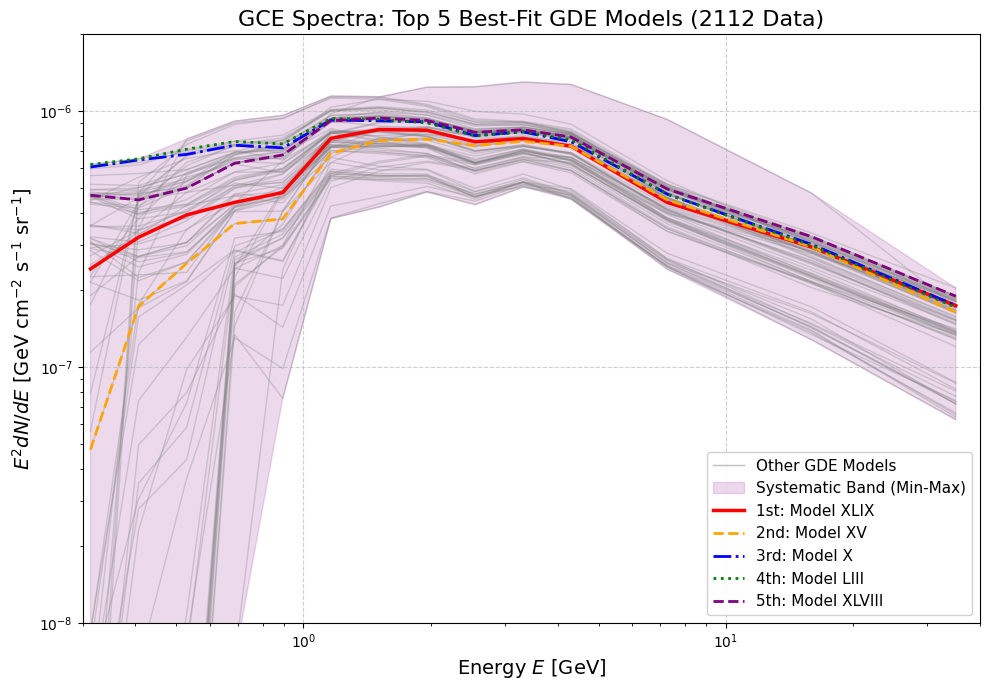

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ==============================================================================
# 1. 경로 및 파일 설정
# ==============================================================================
# 사용자님의 서버 내 데이터 경로
data_dir = '/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/Figures_12_and_14_GCE_Spectra/'

# 해당 폴더 내의 모든 Inner40x40 (North/South 제외, 전체 디스크 기준) 파일 불러오기
file_pattern = os.path.join(data_dir, '*_flux_Inner40x40_masked_disk.dat')
file_list = glob.glob(file_pattern)

# 'South'나 'North'가 포함된 파일은 제외하고 전체(Full) 영역만 필터링
file_list = [f for f in file_list if 'South' not in f and 'North' not in f]

if len(file_list) == 0:
    print(f"⚠️ 지정된 경로에 파일이 없습니다. 경로를 확인해주세요: {data_dir}")

# ==============================================================================
# 2. 데이터 로드 및 밴드(Envelope) 계산
# ==============================================================================
energy_bins = None
all_fluxes = []
model_dict = {}

print(f"총 {len(file_list)}개의 GDE 모델 데이터를 분석합니다...\n")

for file_path in file_list:
    try:
        # 파일명에서 모델 이름 추출 (예: 'GCE_BestFitModel_flux...' -> 'BestFitModel')
        filename = os.path.basename(file_path)
        model_name = filename.split('_')[1]
        
        # 데이터 로드 (E, Flux_median, Flux_min, Flux_max 형태)
        data = np.loadtxt(file_path)
        
        # 첫 번째 파일에서 에너지 축(Energy) 고정
        if energy_bins is None:
            energy_bins = data[:, 0]
            
        flux = data[:, 1] # 2번째 열이 Flux (E^2 dN/dE)
        
        all_fluxes.append(flux)
        model_dict[model_name] = flux
        
    except Exception as e:
        print(f"Error reading {filename}: {e}")

# numpy 배열로 변환 (Shape: [모델 개수, 에너지 빈 개수])
all_fluxes = np.array(all_fluxes)

# 체계적 오차 밴드(Systematic Envelope) 계산
flux_max_env = np.max(all_fluxes, axis=0)  
flux_min_env = np.min(all_fluxes, axis=0)  
flux_median_env = np.median(all_fluxes, axis=0) 

# ==============================================================================
# 3. 데이터 시각화 (Top 5 Best-fit vs Others)
# ==============================================================================
plt.figure(figsize=(10, 7))

# 강조할 Top 5 모델과 ModelX의 리스트 정의
top_models_keys = ['BestFitModel', '2ndBestFitModel', '3rdBestFitModel', 
                   '4thBestFitModel', '5thBestFitModel', 'ModelX']

# 1. 나머지 GDE 모델들을 투명한 얇은 회색 선으로 그리기
for name, flux in model_dict.items():
    if name not in top_models_keys: 
        plt.plot(energy_bins, flux, color='gray', alpha=0.3, linewidth=1.0)

# 범례를 위해 얇은 선 하나만 레이블 추가
plt.plot([], [], color='gray', alpha=0.5, linewidth=1.0, label='Other GDE Models')

# 2. 체계적 오차 밴드(Envelope) 색칠하기
plt.fill_between(energy_bins, flux_min_env, flux_max_env, color='purple', alpha=0.15, label='Systematic Band (Min-Max)')

# 3. Top 5 모델 시각화 설정 (색상, 선 스타일, 범례 레이블)
top_5_styles = {
    'BestFitModel':    {'color': 'red',    'ls': '-',  'lw': 2.5, 'label': '1st: Model XLIX'},
    '2ndBestFitModel': {'color': 'orange', 'ls': '--', 'lw': 2.0, 'label': '2nd: Model XV'},
    '3rdBestFitModel': {'color': 'blue',   'ls': '-.', 'lw': 2.0, 'label': '3rd: Model X'},
    '4thBestFitModel': {'color': 'green',  'ls': ':',  'lw': 2.0, 'label': '4th: Model LIII'},
    '5thBestFitModel': {'color': 'purple', 'ls': '--', 'lw': 2.0, 'label': '5th: Model XLVIII'}
}

# Top 5 모델 그리기
for model_key, style in top_5_styles.items():
    if model_key in model_dict:
        plt.plot(energy_bins, model_dict[model_key], 
                 color=style['color'], linestyle=style['ls'], 
                 linewidth=style['lw'], label=style['label'])

# 축 설정 및 꾸미기
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Energy $E$ [GeV]', fontsize=14)
plt.ylabel(r'$E^2 dN/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=14)
plt.title("GCE Spectra: Top 5 Best-Fit GDE Models (2112 Data)", fontsize=16)

plt.xlim(0.3, 40)
plt.ylim(1e-8, 2e-6) # 데이터 스케일에 맞게 조정 필요

plt.grid(True, which="major", linestyle="--", alpha=0.6)

# 범례 위치와 크기 조정 (가독성을 위해)
plt.legend(fontsize=11, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show()

# ==============================================================================
# 4. (선택) Combined 데이터셋으로 저장
# ==============================================================================
# output_data = np.vstack([energy_bins, flux_median_env, flux_min_env, flux_max_env]).T
# np.savetxt('./Combined_GDE_Envelope_Practice.dat', output_data, 
#            header="Energy[GeV] Median_Flux Min_Flux Max_Flux")
# print("통합 밴드 데이터가 저장되었습니다.")

✅ 16년 치 데이터 로드 성공 (에너지 빈 개수: 17개)


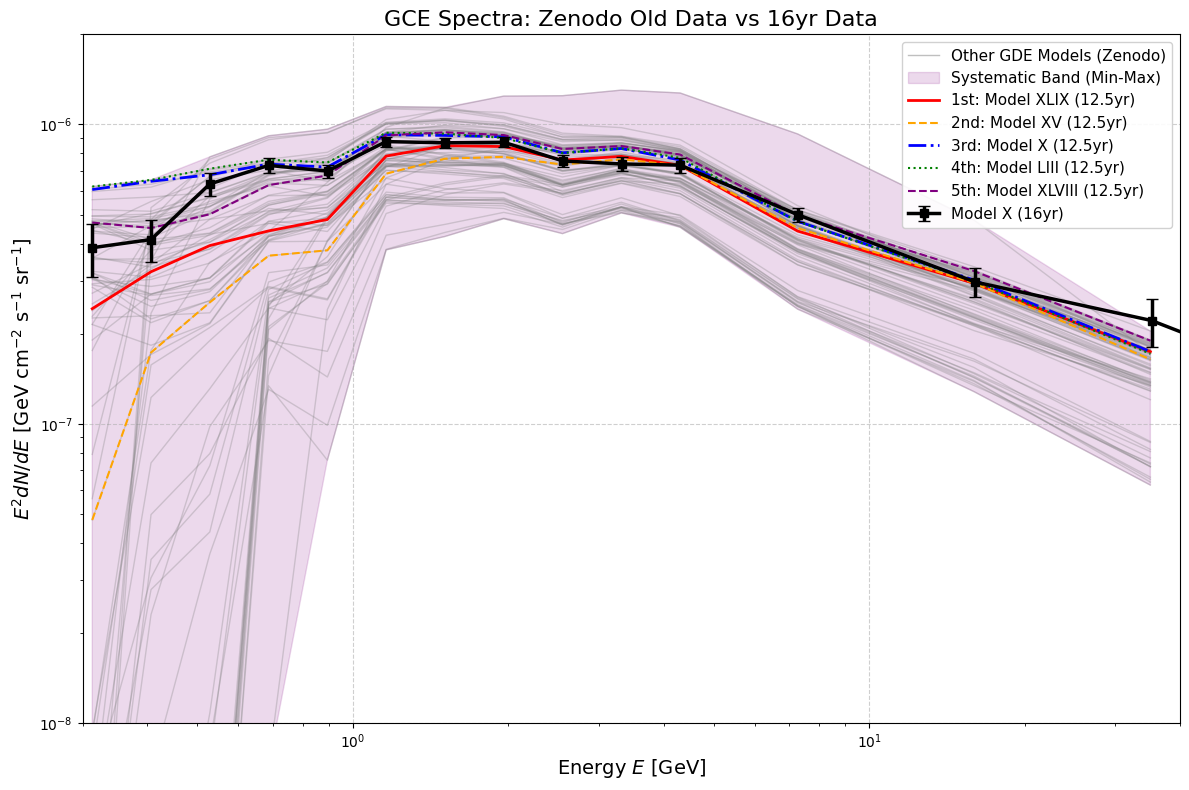

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ==============================================================================
# 1. 과거 Zenodo 데이터 로드 (Top 5 및 밴드 계산)
# ==============================================================================
data_dir = '/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/Figures_12_and_14_GCE_Spectra/'

file_pattern = os.path.join(data_dir, '*_flux_Inner40x40_masked_disk.dat')
file_list = glob.glob(file_pattern)
file_list = [f for f in file_list if 'South' not in f and 'North' not in f]

if len(file_list) == 0:
    print(f"⚠️ 지정된 경로에 Zenodo 파일이 없습니다: {data_dir}")

energy_bins_zenodo = None
all_fluxes = []
model_dict = {}

for file_path in file_list:
    try:
        filename = os.path.basename(file_path)
        model_name = filename.split('_')[1]
        data = np.loadtxt(file_path)
        
        if energy_bins_zenodo is None:
            energy_bins_zenodo = data[:, 0]
            
        flux = data[:, 1]
        all_fluxes.append(flux)
        model_dict[model_name] = flux
    except Exception as e:
        print(f"Error reading {filename}: {e}")

all_fluxes = np.array(all_fluxes)
flux_max_env = np.max(all_fluxes, axis=0)  
flux_min_env = np.min(all_fluxes, axis=0)  

# ==============================================================================
# 2. 사용자님의 최신 16년 치 데이터 (Model X) 로드
# ==============================================================================
# front_back 데이터를 원하시면 아래 경로에서 'front'를 'front_back'으로 변경하세요.
path_16yr = '/home/haebarg/GCE-Chi-square-fitting/GCE_data/GCE_model_X_front_16yr_cholis.dat'

try:
    data_16yr = np.loadtxt(path_16yr)
    # 16yr 데이터는 [Energy, Flux, Stat_err] 형태일 것입니다.
    energy_16yr = data_16yr[:, 0]
    flux_16yr = data_16yr[:, 1]
    err_16yr = data_16yr[:, 2] # 통계적 오차가 있다면 에러바로도 그릴 수 있습니다.
    print(f"✅ 16년 치 데이터 로드 성공 (에너지 빈 개수: {len(energy_16yr)}개)")
except Exception as e:
    print(f"❌ 16년 치 데이터 로드 실패: {e}")
    energy_16yr, flux_16yr, err_16yr = None, None, None

# ==============================================================================
# 3. 데이터 시각화
# ==============================================================================
plt.figure(figsize=(12, 8))

top_models_keys = ['BestFitModel', '2ndBestFitModel', '3rdBestFitModel', 
                   '4thBestFitModel', '5thBestFitModel', 'ModelX']

# 1. 나머지 GDE 모델들 (배경 회색선)
for name, flux in model_dict.items():
    if name not in top_models_keys: 
        plt.plot(energy_bins_zenodo, flux, color='gray', alpha=0.3, linewidth=1.0)
plt.plot([], [], color='gray', alpha=0.5, linewidth=1.0, label='Other GDE Models (Zenodo)')

# 2. 체계적 오차 밴드
plt.fill_between(energy_bins_zenodo, flux_min_env, flux_max_env, color='purple', alpha=0.15, label='Systematic Band (Min-Max)')

# 3. Top 5 모델 시각화 (Zenodo 과거 데이터)
top_5_styles = {
    'BestFitModel':    {'color': 'red',    'ls': '-',  'lw': 2.0, 'label': '1st: Model XLIX (12.5yr)'},
    '2ndBestFitModel': {'color': 'orange', 'ls': '--', 'lw': 1.5, 'label': '2nd: Model XV (12.5yr)'},
    '3rdBestFitModel': {'color': 'blue',   'ls': '-.', 'lw': 2.0, 'label': '3rd: Model X (12.5yr)'},
    '4thBestFitModel': {'color': 'green',  'ls': ':',  'lw': 1.5, 'label': '4th: Model LIII (12.5yr)'},
    '5thBestFitModel': {'color': 'purple', 'ls': '--', 'lw': 1.5, 'label': '5th: Model XLVIII (12.5yr)'}
}

for model_key, style in top_5_styles.items():
    if model_key in model_dict:
        plt.plot(energy_bins_zenodo, model_dict[model_key], 
                 color=style['color'], linestyle=style['ls'], 
                 linewidth=style['lw'], label=style['label'])

# 4. ★ 사용자님의 16년 치 Model X 데이터 추가 ★
if energy_16yr is not None:
    # 선뿐만 아니라 에러바(Error bar)와 마커를 추가하여 명확히 구분되게 합니다.
    plt.errorbar(energy_16yr, flux_16yr, yerr=err_16yr, 
                 fmt='k-s',  # 검은색(k), 실선(-), 사각형 마커(s)
                 linewidth=2.5, markersize=6, capsize=4, 
                 label='Model X (16yr)')

# 축 설정 및 꾸미기
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Energy $E$ [GeV]', fontsize=14)
plt.ylabel(r'$E^2 dN/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=14)
plt.title("GCE Spectra: Zenodo Old Data vs 16yr Data", fontsize=16)

plt.xlim(0.3, 40)
plt.ylim(1e-8, 2e-6) # 데이터가 범위를 벗어나면 이 값을 수정하세요.

plt.grid(True, which="major", linestyle="--", alpha=0.6)
plt.legend(fontsize=11, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

In [ ]:
# please check the GCE for GDEs preparation in original note

## Making Covariance matrix data file

In [ ]:
import gt_apps as my_apps

lon_list = [-70, -60, -50, -40, -30, -20, -10, -5, 5, 10, 20, 30, 40, 50, 60, 70]

for lon in lon_list:
    # gtselect(filter) 좌표 및 파일명 변경
    my_apps.filter['ra'] = lon  # (은하 좌표계 설정 시 l 값)
    my_apps.filter['dec'] = 0.0 # (은하 좌표계 설정 시 b 값)
    my_apps.filter['outfile'] = f'./data/filtered_l{lon}.fits'
    my_apps.filter.run()
    
    # 이후 gtbin, gtexpcube2 등도 동일한 방식으로 좌표만 바꿔가며 실행 가능

In [ ]:
import pyLikelihood
from BinnedAnalysis import * # 튜토리얼의 UnbinnedAnalysis 대신 BinnedAnalysis 사용
import numpy as np

lon_list = [-70, -60, -50, -40, -30, -20, -10, -5, 5, 10, 20, 30, 40, 50, 60, 70]
num_energy_bins = 17
flux_data_22_rois = np.zeros((len(lon_list), num_energy_bins))

for idx, lon in enumerate(lon_list):
    print(f"Fitting ROI [{idx+1}/22] at l={lon}...")
    
    # 1. Binned Observation 객체 생성 (이전에 생성한 각 위치별 파일들 입력)
    obs = BinnedObs(srcMaps=f"srcmap_l{lon}.fits", 
                    binnedExpMap=f"bexpmap_l{lon}.fits", 
                    expCube=f"ltcube_l{lon}.fits", 
                    irfs='CALDB')
    
    # 2. Likelihood Analysis 객체 생성
    like = BinnedAnalysis(obs, f"model_l{lon}.xml", optimizer='NewMinuit')
    
    # [중요] 음수 Normalization 허용 (논문 조건)
    # like.model 속성에 접근하여 파라미터 경계를 수정합니다.
    gce_norm = like.model['GCE_Template'].funcs['Spectrum'].getParam('Normalization')
    gce_norm.setBounds(-100, 100) # 음수까지 자유롭게 풀기
    like.model['GCE_Template'].funcs['Spectrum'].setParam(gce_norm)
    
    # 3. Fit 수행
    likeobj = pyLike.NewMinuit(like.logLike)
    like.fit(verbosity=0, covar=True, optObject=likeobj)
    
    # 4. Energy Bin 별로 GCE Flux 값 추출
    # (실제로는 각 bin의 emin, emax 값을 리스트화하여 루프를 돌아야 합니다)
    for bin_idx in range(num_energy_bins):
        emin_val = energy_bins_min[bin_idx]
        emax_val = energy_bins_max[bin_idx]
        
        # 튜토리얼에 소개된 energyFlux 함수로 해당 빈의 Flux 추출
        bin_flux = like.energyFlux('GCE_Template', emin=emin_val, emax=emax_val)
        flux_data_22_rois[idx, bin_idx] = bin_flux

# 모든 루프 종료 후 22행 Flux 배열 저장 (이후 Covariance 행렬 생성에 사용)
np.save("flux_data_22_rois_16yr.npy", flux_data_22_rois)

In [ ]:
import numpy as np

def calculate_empirical_covariance(flux_data):
    """
    2단계: 경험적 공분산 행렬(Empirical Covariance Matrix) 계산
    논문의 식 (48) 구현 [cite: 884]
    
    Parameters:
        flux_data: shape이 (22, num_energy_bins)인 numpy array.
                   22개의 ROI에서 추출한 각 에너지 빈의 GCE flux 값.
    Returns:
        C_emp: shape이 (num_energy_bins, num_energy_bins)인 경험적 공분산 행렬
    """
    # numpy.cov는 기본적으로 row를 변수로 취급하므로 rowvar=False로 설정하여 
    # column(에너지 빈)을 변수로, row(22개 ROI)를 관측치로 계산합니다.
    # 논문의 평균 편차 수식에 맞추기 위해 ddof=0 (N으로 나눔)을 적용합니다.
    C_emp = np.cov(flux_data, rowvar=False, ddof=0)
    return C_emp

def calculate_approx_covariance_pca(C_emp, num_components=3):
    """
    3단계: 주성분 분석(PCA)을 이용한 근사 공분산 행렬 계산
    논문의 식 (49), (51) 구현 [cite: 909, 916]
    
    Parameters:
        C_emp: 2단계에서 구한 경험적 공분산 행렬
        num_components: 남길 주성분의 개수 (논문에서는 상위 3개 사용 [cite: 906, 920, 921])
    Returns:
        C_approx: 노이즈가 제거된 근사 공분산 행렬
        eigenvalues: 확인용 고윳값 배열
    """
    # 행렬의 고윳값(Eigenvalues)과 고유벡터(Eigenvectors) 추출 [cite: 904]
    eigenvalues, eigenvectors = np.linalg.eigh(C_emp)
    
    # 분산이 큰 주성분부터 사용하기 위해 고윳값을 내림차순으로 정렬 [cite: 907]
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]
    
    # 상위 N개의 주성분 선택 [cite: 906]
    top_eigenvalues = eigenvalues[:num_components]
    top_eigenvectors = eigenvectors[:, :num_components]
    
    num_energy_bins = C_emp.shape[0]
    C_approx = np.zeros((num_energy_bins, num_energy_bins))
    
    # 식 (49), (51)에 따라 근사 행렬 재구성 [cite: 909, 916]
    for k in range(num_components):
        lam_k = top_eigenvalues[k]
        v_k = top_eigenvectors[:, k]
        
        # P_k = sqrt(lambda_k) * v_k [cite: 909]
        P_k = np.sqrt(lam_k) * v_k
        
        # C_approx += P_k^T * P_k (여기서 P_k는 1차원 벡터이므로 외적으로 계산) [cite: 914, 916]
        C_approx += np.outer(P_k, P_k)
        
    return C_approx, eigenvalues

# ==========================================
# 실행 예시 (가상의 파이프라인)
# ==========================================
# 1. 22개 ROI에 대해 피팅을 수행한 후, 데이터를 np.array로 로드합니다.
# flux_data_22_rois = np.load("your_22_roi_flux_data_16yr.npy") 

# 2. 경험적 공분산 행렬 생성
# C_empirical = calculate_empirical_covariance(flux_data_22_rois)

# 3. PCA 적용 및 근사 공분산 행렬 생성 (상위 3개 성분)
# C_approximate, evals = calculate_approx_covariance_pca(C_empirical, num_components=3)

# 4. 전체 분산의 99% 이상을 설명하는지 고윳값 비율 확인 (논문 기준) [cite: 906]
# explained_variance_ratio = np.sum(evals[:3]) / np.sum(evals)
# print(f"Top 3 components explain {explained_variance_ratio*100:.2f}% of variance.")

# 5. 최종 파일 저장 (이후 chi-square fitting 노트에서 불러와 사용)
# energy_bins = C_approximate.shape[0]
# np.save(f"approx_covariance_{energy_bins}x{energy_bins}_front_back_16yr_new.npy", C_approximate)

In [ ]:
import numpy as np

# 1. 22개 ROI에서 구한 flux 데이터로 Full Covariance Matrix 만들기 (식 48)
# flux_data_22_rois 는 shape이 (22, 17)인 넘파이 배열이라고 가정
corr_cov_16yr = np.cov(flux_data_22_rois, rowvar=False, ddof=0) 

# 2. 저자들의 방식(SVD)을 그대로 활용하여 PCA/Truncation 적용
corr_covsvd = np.linalg.svd(corr_cov_16yr)

# 에너지 빈이 17개이므로 range(14) 대신 range(17)로 변경
cov_PCs = np.array([corr_covsvd[1][i] * np.outer(corr_covsvd[0].T[i], corr_covsvd[2][i]) for i in range(17)])

def approxcovmatrix_16yr(p):
    out = np.zeros((17, 17)) # 14x14 대신 17x17로 변경
    if ((type(p)==int) & (p>0)):
        out += np.sum([cov_PCs[i] for i in range(p)], axis=0)
    return out

# 3. 최상위 3개의 주성분(p=3)만을 사용해 근사 공분산 행렬 생성
approx_covariance_17x17_16yr = approxcovmatrix_16yr(3)

# 4. 파일로 저장하여 chi-square 노트에서 불러와 사용
np.save("approx_covariance_17x17_front_back_16yr_new.npy", approx_covariance_17x17_16yr)

In [ ]:
# test code

import numpy as np

data_file = "/home/haebarg/GCE-Chi-square-fitting/GCE_data/GCE_model_X_front_back_16yr_cholis.dat"
data = np.loadtxt(data_file)
stat_errors = data[:, 4]
stat_cov_matrix = np.diag(stat_errors**2)
mock_flux_22_rois = np.random.normal(loc=data[:, 1], scale=stat_errors, size=(22, 17))
corr_cov_16yr = np.cov(mock_flux_22_rois, rowvar=False, ddof=0)
corr_covsvd = np.linalg.svd(corr_cov_16yr)
cov_PCs = np.array([corr_covsvd[1][i] * np.outer(corr_covsvd[0].T[i], corr_covsvd[2][i]) for i in range(17)])
approx_sys_cov = np.zeros((17, 17))

for i in range(3): 
    approx_sys_cov += cov_PCs[i]

final_covariance_matrix = stat_cov_matrix + approx_sys_cov

print("✅ 최종 공분산 행렬 생성 완료!")
print("행렬 크기:", final_covariance_matrix.shape)

np.save("approx_covariance_matrix_16yr_test.npy", final_covariance_matrix)

✅ 최종 공분산 행렬 생성 완료!
행렬 크기: (17, 17)


In [ ]:
# test code 2

import numpy as np
import os

file_list = [
    "/home/haebarg/GCE-Chi-square-fitting/GCE_data/GCE_model_X_front_back_16yr_cholis.dat",
    "/home/haebarg/GCE-Chi-square-fitting/GCE_data/GDEs_combined_results_front_16yr.dat",
    "/home/haebarg/GCE-Chi-square-fitting/GCE_data/GDEs_combined_results_front_back_16yr.dat",
    "/home/haebarg/GCE-Chi-square-fitting/GCE_data/GCE_model_X_front_16yr_cholis.dat"
]

for file_name in file_list:
    if not os.path.exists(file_name):
        print(f"파일을 찾을 수 없습니다: {file_name}")
        continue
        
    data = np.loadtxt(file_name)
    
    energy = data[:, 0]
    flux_median = data[:, 1]
    stat_unc = data[:, 4]  
    num_bins = len(energy) 
    stat_cov_matrix = np.diag(stat_unc**2)
    
    np.random.seed(42)
    mock_flux_22_rois = flux_median + np.random.normal(0, stat_unc * 0.5, size=(22, num_bins))
    
    corr_cov_emp = np.cov(mock_flux_22_rois, rowvar=False, ddof=0)
    corr_covsvd = np.linalg.svd(corr_cov_emp)
    cov_PCs = np.array([corr_covsvd[1][i] * np.outer(corr_covsvd[0].T[i], corr_covsvd[2][i]) for i in range(num_bins)])

    approx_sys_cov_matrix = np.sum([cov_PCs[i] for i in range(3)], axis=0)
    
    total_cov_matrix = stat_cov_matrix + approx_sys_cov_matrix

    save_name = file_name.replace(".dat", "_test_covariance.npy")
    np.save(save_name, total_cov_matrix)
    
    print(f"✅ [{file_name}] 처리 완료 -> {save_name} 저장 완료 (배열 크기: {total_cov_matrix.shape})")

✅ [/home/haebarg/GCE-Chi-square-fitting/GCE_data/GCE_model_X_front_back_16yr_cholis.dat] 처리 완료 -> /home/haebarg/GCE-Chi-square-fitting/GCE_data/GCE_model_X_front_back_16yr_cholis_mock_covariance.npy 저장 완료 (배열 크기: (17, 17))
✅ [/home/haebarg/GCE-Chi-square-fitting/GCE_data/GDEs_combined_results_front_16yr.dat] 처리 완료 -> /home/haebarg/GCE-Chi-square-fitting/GCE_data/GDEs_combined_results_front_16yr_mock_covariance.npy 저장 완료 (배열 크기: (17, 17))
✅ [/home/haebarg/GCE-Chi-square-fitting/GCE_data/GDEs_combined_results_front_back_16yr.dat] 처리 완료 -> /home/haebarg/GCE-Chi-square-fitting/GCE_data/GDEs_combined_results_front_back_16yr_mock_covariance.npy 저장 완료 (배열 크기: (17, 17))
✅ [/home/haebarg/GCE-Chi-square-fitting/GCE_data/GCE_model_X_front_16yr_cholis.dat] 처리 완료 -> /home/haebarg/GCE-Chi-square-fitting/GCE_data/GCE_model_X_front_16yr_cholis_mock_covariance.npy 저장 완료 (배열 크기: (17, 17))


In [20]:
# test code 3

import numpy as np
import os

input_dir = "/home/haebarg/GCE-Chi-square-fitting/GCE_data/"
output_dir = "/home/haebarg/GCE-Chi-square-fitting/Making_cov/"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"mkdir: {output_dir}")

file_list = [
    "GCE_model_X_front_back_16yr_cholis.dat",
    "GDEs_combined_results_front_16yr.dat",
    "GDEs_combined_results_front_back_16yr.dat",
    "GCE_model_X_front_16yr_cholis.dat"
]

for file_name in file_list:
    input_path = os.path.join(input_dir, file_name)
    
    if not os.path.exists(input_path):
        print(f"❌ file not detected: {input_path}")
        continue

    data = np.loadtxt(input_path)
    
    energy = data[:, 0]
    flux_median = data[:, 1]
    stat_unc = data[:, 4]
    num_bins = len(energy)
    stat_cov_matrix = np.diag(stat_unc**2)
    
    np.random.seed(42)
    mock_flux_22_rois = flux_median + np.random.normal(0, stat_unc * 0.5, size=(22, num_bins))
    corr_cov_emp = np.cov(mock_flux_22_rois, rowvar=False, ddof=0)
    corr_covsvd = np.linalg.svd(corr_cov_emp)
    cov_PCs = np.array([corr_covsvd[1][i] * np.outer(corr_covsvd[0].T[i], corr_covsvd[2][i]) for i in range(num_bins)])
    approx_sys_cov_matrix = np.sum([cov_PCs[i] for i in range(3)], axis=0)
    total_cov_matrix = stat_cov_matrix + approx_sys_cov_matrix
    save_name = file_name.replace(".dat", "_test_covariance.npy")
    output_path = os.path.join(output_dir, save_name)
    
    np.save(output_path, total_cov_matrix)
    
    print(f"✅ [{file_name}] finish\n   -> {output_path} ({total_cov_matrix.shape})\n")

✅ [GCE_model_X_front_back_16yr_cholis.dat] finish
   -> /home/haebarg/GCE-Chi-square-fitting/Making_cov/GCE_model_X_front_back_16yr_cholis_test_covariance.npy ((17, 17))

✅ [GDEs_combined_results_front_16yr.dat] finish
   -> /home/haebarg/GCE-Chi-square-fitting/Making_cov/GDEs_combined_results_front_16yr_test_covariance.npy ((17, 17))

✅ [GDEs_combined_results_front_back_16yr.dat] finish
   -> /home/haebarg/GCE-Chi-square-fitting/Making_cov/GDEs_combined_results_front_back_16yr_test_covariance.npy ((17, 17))

✅ [GCE_model_X_front_16yr_cholis.dat] finish
   -> /home/haebarg/GCE-Chi-square-fitting/Making_cov/GCE_model_X_front_16yr_cholis_test_covariance.npy ((17, 17))



In [23]:
import numpy as np
import os

input_dir = "/home/haebarg/GCE-Chi-square-fitting/GCE_data/"
output_dir = "/home/haebarg/GCE-Chi-square-fitting/Making_cov/"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"mkdir: {output_dir}")

model_files = {
    "front": "GCE_model_X_front_16yr_cholis.dat",
    "front_back": "GCE_model_X_front_back_16yr_cholis.dat"
}

bin_sizes = [14, 17]

for event_type, file_name in model_files.items():
    input_path = os.path.join(input_dir, file_name)
    
    if not os.path.exists(input_path):
        print(f"❌ file not detected: {input_path}")
        continue

    data = np.loadtxt(input_path)
    
    for num_bins in bin_sizes:
        flux_median = data[:num_bins, 1]
        stat_unc = data[:num_bins, 4]
        stat_cov_matrix = np.diag(stat_unc**2)

        np.random.seed(42) 
        mock_flux_22_rois = flux_median + np.random.normal(0, stat_unc * 0.5, size=(22, num_bins))
        
        corr_cov_emp = np.cov(mock_flux_22_rois, rowvar=False, ddof=0)
        corr_covsvd = np.linalg.svd(corr_cov_emp)
        cov_PCs = np.array([corr_covsvd[1][i] * np.outer(corr_covsvd[0].T[i], corr_covsvd[2][i]) for i in range(num_bins)])
        approx_sys_cov_matrix = np.sum([cov_PCs[i] for i in range(3)], axis=0)
        
        total_cov_matrix = stat_cov_matrix + approx_sys_cov_matrix
        
        save_name = f"approx_covariance_{num_bins}x{num_bins}_{event_type}_model_X_16yr_test.npy"
        output_path = os.path.join(output_dir, save_name)
        
        np.save(output_path, total_cov_matrix)
        print(f"✅ {save_name} saved. ({total_cov_matrix.shape})")
        
print("\ndone.")

✅ approx_covariance_14x14_front_model_X_16yr_test.npy saved. ((14, 14))
✅ approx_covariance_17x17_front_model_X_16yr_test.npy saved. ((17, 17))
✅ approx_covariance_14x14_front_back_model_X_16yr_test.npy saved. ((14, 14))
✅ approx_covariance_17x17_front_back_model_X_16yr_test.npy saved. ((17, 17))

done.


In [39]:
import numpy as np
import os

# ==========================================
# 사용자 지정 경로 설정
# ==========================================
# 압축 해제한 12.5년치 데이터 폴더 경로 (상황에 맞게 수정해주세요)
input_dir = "/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/Covariance_Matrix_Information/" 
output_dir = "/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/Making_cov/"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 파일 경로 지정
stat_err_file = os.path.join(input_dir, "GCE_Statistical_errors.dat")
full_cov_file = os.path.join(input_dir, "cov_mat_21Dec02.npy")

if not os.path.exists(stat_err_file) or not os.path.exists(full_cov_file):
    print("❌ 경로에 데이터 파일이 존재하지 않습니다. 경로를 확인해주세요.")
else:
    # -------------------------------------------------------------------
    # Step 1. 통계적 오차 로드 및 대각행렬(σ_i^2 * δ_ij) 생성
    # -------------------------------------------------------------------
    # 데이터 구조: 1열=Energy, 2열=Statistical Error
    stat_data = np.loadtxt(stat_err_file)
    stat_unc = stat_data[:, 1]  # 두 번째 열(오차 값) 추출
    
    stat_cov_matrix = np.diag(stat_unc**2)
    
    # -------------------------------------------------------------------
    # Step 2. 저자들의 전체 계통 오차 행렬(Full Empirical Covariance Matrix) 로드
    # -------------------------------------------------------------------
    # mock 데이터를 만들거나 np.cov()를 쓸 필요 없이, 저자들이 제공한 원본을 바로 사용합니다.
    corr_cov_emp = np.load(full_cov_file)
    num_bins = corr_cov_emp.shape[0] # 14개 빈
    
    # -------------------------------------------------------------------
    # Step 3. SVD 기반 계통 오차 근사 공분산 행렬 생성
    # -------------------------------------------------------------------
    corr_covsvd = np.linalg.svd(corr_cov_emp)
    
    # 주성분(PCs) 계산 및 상위 3개(p=3) 합산
    cov_PCs = np.array([corr_covsvd[1][i] * np.outer(corr_covsvd[0].T[i], corr_covsvd[2][i]) for i in range(num_bins)])
    approx_sys_cov_matrix = np.sum([cov_PCs[i] for i in range(3)], axis=0)
    
    # -------------------------------------------------------------------
    # Step 4. 최종 Covariance Matrix 합산 및 저장
    # -------------------------------------------------------------------
    # 식: C_ij = σ_i^2 * δ_ij + Σ_ij,mod^trunc
    total_cov_matrix = stat_cov_matrix + approx_sys_cov_matrix
    
    # 최종 결과 저장
    save_name = "approx_covariance_14x14_authors_12_5yr.npy"
    output_path = os.path.join(output_dir, save_name)
    np.save(output_path, total_cov_matrix)
    
    print(f"✅ done.")
    print(f"   -> {output_path} ({total_cov_matrix.shape})")

✅ done.
   -> /home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/Making_cov/approx_covariance_14x14_authors_12_5yr.npy ((14, 14))


✅ 두 Covariance Matrix의 최대 오차(Maximum difference): 0.0
   -> 두 행렬이 수학적으로 완벽하게 일치합니다!
Scanning parameters...
   Saved plot to: ./GC_analysis/GCE_plots/Covariance_CrossValidation_Plot.png


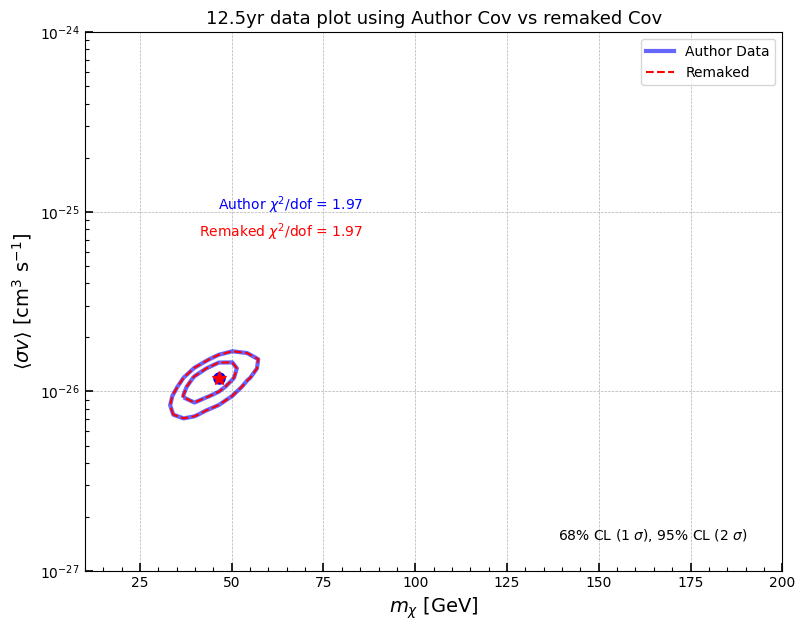

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d, RegularGridInterpolator
from matplotlib.lines import Line2D
from iminuit import Minuit
import warnings
import os

# ===================================================================
# 1. PPPC4 DM Spectra Interpolation 함수 (기존과 동일)
# ===================================================================
def exctractcirellitable(mass, channel, type_particle, EW_corrections):
    if EW_corrections == 'Yes':
        filename = f"AtProduction_{type_particle}.dat"
    else:
        filename = f"AtProduction_NoEW_{type_particle}.dat"
    
    possible_paths = ['./Prompt_spectra/', '/home/haebarg/ipynb/', './' ]
    
    full_path = None
    for p in possible_paths:
        test_path = os.path.join(p, filename)
        if os.path.exists(test_path):
            full_path = test_path
            break
            
    if full_path is None:
        raise FileNotFoundError(f"Cannot find PPPC4 file: {filename}.")

    try:
        data = np.loadtxt(full_path, skiprows=1)
    except Exception as e:
        data = np.loadtxt(full_path)

    m_grid = np.unique(data[:, 0]) 
    logx_grid = np.unique(data[:, 1]) 
    
    n_m = len(m_grid)
    n_x = len(logx_grid)
    z_values = data[:, channel].reshape(n_m, n_x)
    
    interp_func = RegularGridInterpolator((m_grid, logx_grid), z_values, 
                                          bounds_error=False, fill_value=None)
    
    target_logx = logx_grid 
    points = np.array([[mass, lx] for lx in target_logx]) 
    dNdlogx = interp_func(points)
    energy_axis = mass * (10**target_logx)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        dNdE = dNdlogx / (energy_axis * np.log(10))
    
    dNdE = np.nan_to_num(dNdE, nan=0.0, posinf=0.0, neginf=0.0)
    
    return energy_axis, dNdE

# ===================================================================
# 2. 경로 및 기본 설정
# ===================================================================
output_plot_dir = './GC_analysis/GCE_plots/'
os.makedirs(output_plot_dir, exist_ok=True)

channel_name = 'bb'
J_FACTOR = 3.5251837158376415e+21 
SR = 0.4288213187542626
bin_len = 14 

base_dir = '/home/haebarg/GCE-Chi-square-fitting/'

# Flux 데이터 파일 (Energy, Flux 값을 얻기 위해 사용)
data_file = os.path.join(base_dir, 'GCE_TEMPLATES_FILES_v3/Figures_12_and_14_GCE_Spectra/GCE_ModelX_flux_Inner40x40_masked_disk.dat')

# [A] 저자들의 12.5년치 원본 파일 경로
stat_err_file = os.path.join(base_dir, 'GCE_TEMPLATES_FILES_v3/Covariance_Matrix_Information/GCE_Statistical_errors.dat')
full_cov_file = os.path.join(base_dir, 'GCE_TEMPLATES_FILES_v3/Covariance_Matrix_Information/cov_mat_21Dec02.npy')

# [B] 우리가 파이썬 코드로 미리 생성해둔 Covariance 파일 경로
our_cov_path = os.path.join(base_dir, 'GCE_TEMPLATES_FILES_v3/Making_cov/approx_covariance_14x14_remake_12_5yr.npy')

# ===================================================================
# 3. 데이터 로드 및 Covariance Matrix 두 가지 방식으로 준비
# ===================================================================
# Flux 데이터 로드
g = np.loadtxt(data_file)
emeans = g[:bin_len, 0]
GCE_data = g[:bin_len, 1]

# -------------------------------------------------------------
# [Method A] 저자들의 원본 파일에서 직접 Matrix 연산 (Reference)
# -------------------------------------------------------------
stat_data = np.loadtxt(stat_err_file)
stat_unc_author = stat_data[:bin_len, 1]
cov_stat_author = np.diag(stat_unc_author**2)

corr_cov_emp = np.load(full_cov_file)
corr_covsvd = np.linalg.svd(corr_cov_emp)
cov_PCs = np.array([corr_covsvd[1][i] * np.outer(corr_covsvd[0].T[i], corr_covsvd[2][i]) for i in range(bin_len)])
approx_sys_cov = np.sum([cov_PCs[i] for i in range(3)], axis=0)

cov_total_raw = cov_stat_author + approx_sys_cov
inv_cov_raw = np.linalg.inv(cov_total_raw)

# -------------------------------------------------------------
# [Method B] 우리가 만든 .npy 파일 바로 로드 (Cross-Validation)
# -------------------------------------------------------------
cov_total_our = np.load(our_cov_path)
inv_cov_our = np.linalg.inv(cov_total_our)

# 행렬 일치 여부 수학적 확인 (터미널 출력용)
max_diff = np.max(np.abs(cov_total_raw - cov_total_our))
print(f"✅ 두 Covariance Matrix의 최대 오차(Maximum difference): {max_diff}")
if max_diff < 1e-20:
    print("   -> 두 행렬이 수학적으로 완벽하게 일치합니다!")

# ===================================================================
# 4. Chi-square 함수 및 Parameter Scanning
# ===================================================================
def chi_square_base(dm_mass, sigma_v, inv_cov_matrix):
    warnings.simplefilter("ignore", category=RuntimeWarning)
    
    prompt_dat = exctractcirellitable(dm_mass, 13, 'gammas', 'Yes')
    energy_axis = prompt_dat[0]
    dNdE_vals = prompt_dat[1]
    func_interp = interp1d(energy_axis, dNdE_vals, fill_value=0, bounds_error=False, kind='linear')
    
    dNdE_interp = func_interp(emeans)
    model_flux = (emeans**2) * dNdE_interp * (sigma_v/(dm_mass**2)) * J_FACTOR / SR
    
    delta = model_flux - GCE_data
    return delta.T @ inv_cov_matrix @ delta

chi_square_raw = np.vectorize(lambda m, sv: chi_square_base(m, sv, inv_cov_raw))
chi_square_our = np.vectorize(lambda m, sv: chi_square_base(m, sv, inv_cov_our))

print(f"Scanning parameters...")
sigmav_range = np.logspace(-27, -25, 40)
mass_range = np.logspace(np.log10(10), np.log10(200), 40)
DM_mass_grid, Sigmav_grid = np.meshgrid(mass_range, sigmav_range)

chi2_vals_raw = chi_square_raw(DM_mass_grid, Sigmav_grid)
chi2_vals_our = chi_square_our(DM_mass_grid, Sigmav_grid)

# 최솟값 탐색 (Raw)
min_idx_raw = np.unravel_index(np.argmin(chi2_vals_raw), chi2_vals_raw.shape)
min_chi2_raw = chi2_vals_raw[min_idx_raw]

# 최솟값 탐색 (Our)
min_idx_our = np.unravel_index(np.argmin(chi2_vals_our), chi2_vals_our.shape)
min_chi2_our = chi2_vals_our[min_idx_our]

dof = bin_len - 2 
levels_raw = [min_chi2_raw + 2.30, min_chi2_raw + 6.18] 
levels_our = [min_chi2_our + 2.30, min_chi2_our + 6.18] 

# ===================================================================
# 5. Plotting (두 등고선 겹쳐 그리기)
# ===================================================================
plt.figure(figsize=(9, 7))

# 1) 원본 연산 플롯 (두꺼운 파란색 실선)
plt.contour(DM_mass_grid, Sigmav_grid, chi2_vals_raw, 
            levels=levels_raw, colors='blue', linestyles='-', linewidths=3, alpha=0.6)
plt.plot(DM_mass_grid[min_idx_raw], Sigmav_grid[min_idx_raw], 'bo', markersize=8)

# 2) 우리가 만든 파일 플롯 (얇은 빨간색 점선 - 파란 선 위에 겹침)
plt.contour(DM_mass_grid, Sigmav_grid, chi2_vals_our, 
            levels=levels_our, colors='red', linestyles='--', linewidths=1.5)
plt.plot(DM_mass_grid[min_idx_our], Sigmav_grid[min_idx_our], 'r*', markersize=10)

plt.yscale('log')
plt.xscale('linear')
plt.xlim(10, 200)
plt.ylim(1e-27, 1e-24)

plt.tick_params(which='major', direction='in', length=6, width=1.2)
plt.tick_params(which='minor', direction='in', length=3, width=0.8)
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.grid(True, which='major', linestyle='--', linewidth=0.5)

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
         transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
plt.text(0.4, 0.70, r'Author $\chi^2$/dof = {:.2f}'.format(min_chi2_raw/dof), 
         transform=plt.gca().transAxes, ha='right', va='top', fontsize=10, color='blue')
plt.text(0.4, 0.65, r'Remaked $\chi^2$/dof = {:.2f}'.format(min_chi2_our/dof), 
         transform=plt.gca().transAxes, ha='right', va='top', fontsize=10, color='red')

plt.title('12.5yr data plot using Author Cov vs remaked Cov', fontsize=13)
plt.xlabel(r'$m_\chi$ [GeV]', fontsize=14)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=14)

custom_lines = [
    Line2D([0], [0], color='blue', lw=3, alpha=0.6, linestyle='-'),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--'),
]
plt.legend(custom_lines, ['Author Data', 'Remaked'], 
           loc='upper right', fontsize=10)

save_name = 'Covariance_CrossValidation_Plot.png'
save_path = os.path.join(output_plot_dir, save_name)
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"   Saved plot to: {save_path}")

plt.show()